## 1. dataframe

In [83]:
import json
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import seaborn as sns
from collections import Counter
from itertools import combinations
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from itertools import combinations
import numpy as np
import pandas as pd
import re

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def load_and_analyze(metadata_path, recipes_path):
    """加载数据，数据集概览"""
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
    with open(recipes_path, "r", encoding="utf-8") as f:
        recipes = json.load(f)
    
    df_books = pd.DataFrame(metadata)
    df_recipes = pd.DataFrame(recipes)

    
    return df_books, df_recipes

df_books, df_recipes = load_and_analyze("cookbooks_extracted_metadata.json", "cookbooks_extracted_recipes.json")

print(f"书籍数量: {len(df_books)}")
print(f"菜谱数量: {len(df_recipes)}")
print(f"最早出版年份: {df_books['date'].min()}" if 'date' in df_books.columns else "")
print(f"最晚出版年份: {df_books['date'].max()}" if 'date' in df_books.columns else "")
print(f"民族分类数量: {df_books['ethnic_group'].nunique()}")
print(f"菜系类别数量: {df_books['class1'].nunique()}\n")

print('df_books的column: \n',df_books.columns)
print('\ndf_recipes的column: \n',df_recipes.columns)

# 正确查询特定book_id的年份
print(df_books[df_books['book_id'] == 'jenn']['date'])

书籍数量: 74
菜谱数量: 43670
最早出版年份: 1803
最晚出版年份: 1922
民族分类数量: 13
菜系类别数量: 7

df_books的column: 
 Index(['book_id', 'title', 'subject', 'author', 'publisher', 'publish_region',
       'date', 'language', 'region', 'subregion', 'ethnic_group', 'type',
       'class1', 'class2'],
      dtype='object')

df_recipes的column: 
 Index(['book_id', 'name', 'class1', 'class2', 'ethnic_group', 'region',
       'ingredients', 'implements', 'variations'],
      dtype='object')
42    1870, c1866
Name: date, dtype: object


In [84]:
# df_books.head()

In [85]:
# df_recipes.head()

两者通过book_id相连。

In [86]:
def clean_ethnic_group(s):
    
    """将 ethnic_group 字段标准化并分拆多个民族"""
    if not s or not isinstance(s, str):
        return []
    
    # 拆分多个民族，以逗号分隔，去除空格和统一小写再大写首字母
    groups = [g.strip().capitalize() for g in s.split(',') if g.strip()]
    return groups

# 应用到整个数据框：构建民族列表列
df_books['ethnic_group'] = df_books['ethnic_group'].replace('', np.nan)
df_books['ethnic_group'] = df_books['ethnic_group'].fillna('Unknown')
df_books['ethnic_group_list'] = df_books['ethnic_group'].apply(clean_ethnic_group)
# 展开所有民族，重新统计频数
from collections import Counter
ethnic_flat_list = [group for sublist in df_books['ethnic_group_list'] for group in sublist]
ethnic_counts = pd.Series(Counter(ethnic_flat_list)).sort_values(ascending=False).head(10)

In [87]:
def preprocess_subjects(df):
    unwanted_categories = {"Cookery", "Recipes", "Menus", "Food", "Womencooks", 
                           "Confectionery", "Cookbooks", "Cookeryforthesick", "Liquors", 
                           "Vegetarianism", "Formula", "Medicine,Popular", "Chocolate", "Cocoa",
                           "Groceries", "Military", "Waiters", "Food--Dictionaries","Homeeconomics", 
                           "HomeEconomics","Diet","Juvenileliterature",
                           "Immigrants--UnitedStates"}
    
    def clean_subjects(subjects):
        cleaned = []
        for subject in subjects:
            if subject.startswith("Cookery,"):
                subject = subject.replace("Cookery,", "").strip()
            if subject.startswith("Cookery--"):
                subject = subject.replace("Cookery--", "").strip()
            if subject not in unwanted_categories:
                cleaned.append(subject)
        return cleaned

    df['subject'] = df['subject'].apply(clean_subjects)

def categorize_subjects(subjects):
    categorized = []
    seen = set()  # 用于跟踪已添加的分类
    
    for subject in subjects:
        # 处理American相关分类
        if (subject.startswith("American--") or 
            subject in {"Northeastern", "SouthernStates", "MiddleEastern",
                       "Washington", "California", "Quakercooking", "Virginia", 
                       "Kentucky", "NewEngland", "NewYork", "Pennsylvania", "Ohio"}):
            if "American" not in seen:
                categorized.append("American")
                seen.add("American")
        
        # 处理German相关分类
        elif subject.startswith("Germans--"):
            if "German" not in seen:
                categorized.append("German")
                seen.add("German")
        
        # 其他分类
        elif subject not in seen:  # 避免重复
            categorized.append(subject)
            seen.add(subject)
    
    return categorized

In [88]:
# # 检查原始数据中，年份不是数字而是类似"date": "1894, c1893"的记录
# print("\n原始数据中包含'c'的记录：")
# c_dates = df_books[df_books['date'].astype(str).str.contains('c', case=False, na=False)]
# print(c_dates[['date']].head(5) if not c_dates.empty else "未找到含'c'的记录")

# # 检查数据类型
# print("\n日期列数据类型：", df_books['date'].dtype)
# print("示例值：", df_books['date'].iloc[0], type(df_books['date'].iloc[0]))

In [89]:
# # 创建 df_books 的副本，并预处理 subject 类别
# df_books_copy = df_books.copy()
# preprocess_subjects(df_books_copy)
# df_books_copy['categorized_subject'] = df_books_copy['subject'].apply(categorize_subjects)

# def visualize_dataset_overview(df_books, df_recipes):
#     import matplotlib.pyplot as plt
#     import seaborn as sns
#     import pandas as pd
#     import re
#     # 图形风格设置
#     sns.set(style="whitegrid")
#     plt.rcParams['font.sans-serif'] = ['SimHei']
#     plt.rcParams['axes.unicode_minus'] = False

#     # 设置画布
#     fig, axs = plt.subplots(3, 2, figsize=(18, 16))
#     fig.suptitle("美国食谱数据集概览", fontsize=20)

#     ### 1. 出版年份分布
#     if 'date' in df_books.columns:
#         def extract_year_simple(date_val):
#             date_str = str(date_val)  # 强制转为字符串
            
#             # 查找c后面的4位数字
#             if 'c' in date_str.lower():  
#                 match = re.search(r'c\D*(\d{4})', date_str, re.IGNORECASE)
#                 if match:
#                     # print(f"找到年份: {match.group(1)}")
#                     return int(match.group(1))
            
#             # 查找任何4位数字
#             match = re.search(r'(\d{4})', date_str)
#             if match:
#                 return int(match.group(1))
            
#             return np.nan  
        
#         df_books['date'] = df_books['date'].apply(extract_year_simple)
        
#         valid_years = df_books['date'].dropna()
#         if not valid_years.empty:
#             sns.histplot(valid_years, bins=20, kde=True, ax=axs[0, 0])
#             axs[0, 0].set_title(f"出版年份分布（共{len(valid_years)}条数据）")
#         else:
#             axs[0, 0].text(0.5, 0.5, "无有效年份数据", ha='center')

#     ### 2. 民族分类数量（书籍）
#     if 'ethnic_group' in df_books.columns:
#         # 使用之前构造的标准化频数
#         sns.barplot(x=ethnic_counts.values, y=ethnic_counts.index, ax=axs[0, 1], hue=ethnic_counts.index, legend=False, palette='viridis')
#         axs[0, 1].set_title("Top 10 (标准化)民族分类书籍数量")
#         axs[0, 1].set_xlabel("数量")
#         axs[0, 1].set_ylabel("民族分类")
#         for p in axs[0, 1].patches:
#             axs[0, 1].text(p.get_width() + 1, p.get_y() + p.get_height() / 2, 
#                            int(p.get_width()), va='center')


#     ### 3. 菜系类别数量
#     if 'class1' in df_books.columns:
#         class_counts = df_books['class1'].value_counts().head(10)
#         sns.barplot(x=class_counts.values, y=class_counts.index, ax=axs[1, 0], hue=class_counts.index, legend=False, palette='viridis')
#         axs[1, 0].set_title("菜系类别书籍数量")
#         axs[1, 0].set_xlabel("数量")
#         axs[1, 0].set_ylabel("菜系类别")
#         for p in axs[1, 0].patches:
#             axs[1, 0].text(p.get_width() + 1, p.get_y() + p.get_height() / 2, 
#                            int(p.get_width()), va='center')


#     ### 4. Categorized Subject（书）
#     unique_subjects = df_books_copy.explode('categorized_subject')[['book_id', 'categorized_subject']].drop_duplicates()
#     subject_counts_books = unique_subjects['categorized_subject'].value_counts()
#     sns.barplot(x=subject_counts_books.index, y=subject_counts_books.values, ax=axs[1, 1], 
#                 hue=subject_counts_books.index, legend=False, palette='viridis')
#     axs[1, 1].set_title("书籍主题分布（唯一计数）")
#     axs[1, 1].set_ylabel("数量")
#     axs[1, 1].tick_params(axis='x', rotation=45)
#     for p in axs[1, 1].patches:
#         axs[1, 1].text(p.get_x() + p.get_width() / 2, p.get_height() + 1, 
#                            int(p.get_height()), ha='center')


#     ### 5. Categorized Subject（食谱）
#     book_subjects_exploded = df_books_copy[['book_id', 'categorized_subject']].explode('categorized_subject')
#     recipes_with_subjects = df_recipes.merge(book_subjects_exploded, on='book_id', how='left')
#     subject_counts_recipes = recipes_with_subjects['categorized_subject'].value_counts()
#     sns.barplot(x=subject_counts_recipes.index, y=subject_counts_recipes.values, ax=axs[2, 0], 
#                 hue=subject_counts_recipes.index, legend=False, palette='coolwarm')
#     axs[2, 0].set_title("食谱主题分布")
#     axs[2, 0].set_ylabel("数量")
#     axs[2, 0].tick_params(axis='x', rotation=45)
#     for p in axs[2, 0].patches:
#         axs[2, 0].text(p.get_x() + p.get_width() / 2, p.get_height() + 1, 
#                            int(p.get_height()), ha='center')


#     ### 6. 民族分类（食谱）
#     df_recipes['ethnic_group'] = df_recipes['ethnic_group'].replace('', pd.NA).fillna('Unknown')
#     ethnic_counts_recipes = df_recipes['ethnic_group'].value_counts().head(12)
#     sns.barplot(x=ethnic_counts_recipes.index, y=ethnic_counts_recipes.values, ax=axs[2, 1], 
#                 hue=ethnic_counts_recipes.index, legend=False, palette='mako')
#     axs[2, 1].set_title("Top 12 民族分类（食谱）")
#     axs[2, 1].set_ylabel("数量")
#     axs[2, 1].tick_params(axis='x', rotation=45)
#     for p in axs[2, 1].patches:
#         axs[2, 1].text(p.get_x() + p.get_width() / 2, p.get_height() + 1, 
#                            int(p.get_height()), ha='center')


#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.show()


# # 调用函数
# visualize_dataset_overview(df_books, df_recipes)


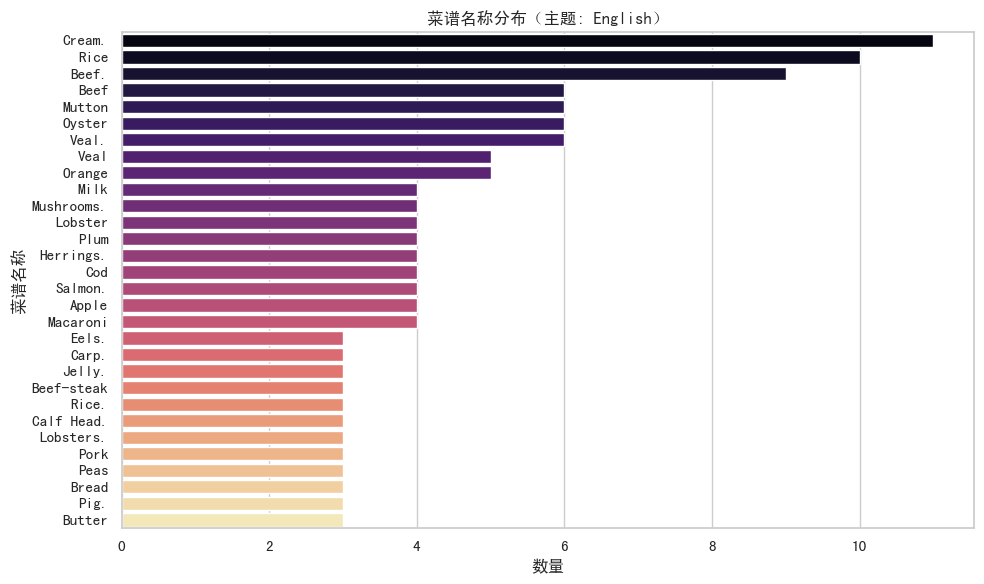

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_recipe_names_by_subject(subject_keyword, df_books_copy, df_recipes):
    # Step 1: 展开主题
    exploded_subjects = df_books_copy[['book_id', 'categorized_subject']].explode('categorized_subject')
    
    # Step 2: 合并到食谱上
    recipes_with_subject = df_recipes.merge(exploded_subjects, on='book_id', how='left')
    
    # Step 3: 筛选指定 subject 的食谱（比如 "American"）
    filtered_recipes = recipes_with_subject[recipes_with_subject['categorized_subject'] == subject_keyword]
    
    # Step 4: 按菜谱名称计数
    name_counts = filtered_recipes['name'].value_counts().sort_values(ascending=False)
    
    # Step 5: 可视化（展示前 20 个）
    plt.figure(figsize=(10, 6))
    sns.barplot(x=name_counts.values[:30], y=name_counts.index[:30], palette='magma')
    plt.title(f"菜谱名称分布（主题: {subject_keyword}）")
    plt.xlabel("数量")
    plt.ylabel("菜谱名称")
    plt.tight_layout()
    plt.show()

# 示例调用
plot_recipe_names_by_subject("English", df_books_copy, df_recipes)


为啥有八本African American的书，相应书籍的食谱那么少？
检测一下

In [91]:
# 统计AfricaAmerican类的频数
# 1. 首先查看所有存在的主题分类
print("所有主题分类：")
print(df_books_copy['categorized_subject'].explode().value_counts())

# 2. 查找所有可能的African American相关主题
african_american_books = df_books_copy[
    df_books_copy['categorized_subject'].apply(
        lambda x: any('african' in s.lower() for s in x) if x else False
    )
]

# 3. 打印找到的书籍
print("\nAfrican American相关主题的书籍：")
if not african_american_books.empty:
    print(african_american_books[['book_id', 'title', 'date', 'categorized_subject']].to_string(index=False))
    
    # 4. 计算对应的菜谱数量
    aa_recipe_counts = df_recipes[
        df_recipes['book_id'].isin(african_american_books['book_id'])
    ].shape[0]
    print(f"\n这些书籍对应的菜谱总数: {aa_recipe_counts}")
    
    # 5. 查看每本书的菜谱数量分布
    recipe_counts = df_recipes[df_recipes['book_id'].isin(african_american_books['book_id'])]
    print("\n每本书的菜谱数量：")
    print(recipe_counts['book_id'].value_counts().reset_index().rename(
        columns={'index': 'book_id', 'book_id': 'recipe_count'}))
else:
    print("没有找到相关主题的书籍")

所有主题分类：
American           57
AfricanAmerican     8
Jewish              6
French              6
Asian               3
English             3
Creole              2
LatinAmerican       2
Italian             2
German              2
Chinese             1
Japanese            1
Swedish             1
Mexican             1
Spanish             1
Indian              1
Name: categorized_subject, dtype: int64

African American相关主题的书籍：
book_id                                                                            title  date                         categorized_subject
   bart                                                              The Ideal Bartender  1917                           [AfricanAmerican]
   cclu        Cooking in old Créole days La cuisine créole à l'usage des petits ménages  1904 [Creole, French, American, AfricanAmerican]
   creo                                                                La Cuisine Creole  1885 [Creole, American, French, AfricanAmerican]
   dish           

好吧，就是没几个食谱（或者书里的食谱没有encode出来）


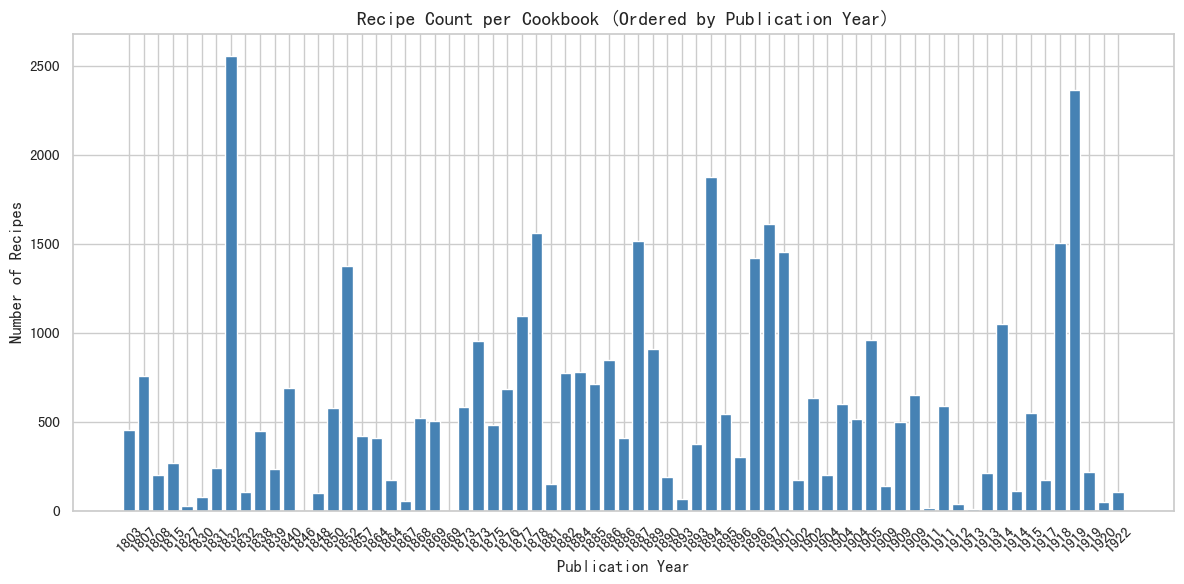

In [92]:
def plot_top_books_by_year_ordered(df_recipes, df_books, top_n=74):
    """
    绘制按出版年份排序的每本书中菜谱数量分布（前 top_n 本书）
    横轴标签改为对应的出版年份
    """
    # 统计每本书的菜谱数量
    recipe_counts = df_recipes['book_id'].value_counts().reset_index()
    recipe_counts.columns = ['book_id', 'recipe_count']
    
    # 从df_books获取出版年份和书名
    books_with_info = df_books[['book_id', 'date', 'title']].copy()
    
    # 合并数据
    merged = recipe_counts.merge(books_with_info, on='book_id', how='left')
   
    # 转换为数值型年份，处理缺失值
    merged['date'] = pd.to_numeric(merged['date'], errors='coerce')
    merged = merged.dropna(subset=['date'])
    
    # 按年份排序
    merged = merged.sort_values('date').head(top_n)
    
    plt.figure(figsize=(12, 6))
    
    # 使用条形图位置索引（0到73），但标签改为年份: 将同一年的书籍放在一起
    x_positions = range(len(merged))
    plt.bar(x_positions, merged['recipe_count'], color='steelblue', width=0.8)
    
    # 设置x轴标签为年份
    plt.xticks(x_positions, merged['date'].astype(int), rotation=45)
    
    plt.title("Recipe Count per Cookbook (Ordered by Publication Year)", fontsize=14)
    plt.xlabel("Publication Year", fontsize=12)
    plt.ylabel("Number of Recipes", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# 调用函数
plot_top_books_by_year_ordered(df_recipes, df_books, top_n=74)

Note：该图中，部分年份有不止一本书的食谱。

## 2. 函数

### 2.1查看某一个subject的书籍年份分布

In [93]:
def analyze_subject_years(subject_keyword, df_books, show_details=True):
    """
    分析指定 subject 的书籍年份分布
    
    Args:
        subject_keyword (str): 要分析的主题，如 "American", "French" 等
        df_books (pd.DataFrame): 包含书籍信息的DataFrame
        show_details (bool): 是否显示详细的书籍信息
    
    Returns:
        pd.Series: 按年份排序的书籍数量统计
    """
    # 1. 预处理：确保 df_books 有正确处理过的 subject
    if 'categorized_subject' not in df_books.columns:
        print("Processing subjects...")
        preprocess_subjects(df_books)
        df_books['categorized_subject'] = df_books['subject'].apply(categorize_subjects)
    
    # 2. 提取年份
    df_books_copy = df_books.copy()
    
    # 确保date列为字符串类型并处理NaN值
    df_books_copy['date'] = df_books_copy['date'].fillna('').astype(str)
    
    # 使用正则表达式提取年份
    def extract_year(date_str):
        try:
            match = re.search(r'\d{4}', str(date_str))
            return float(match.group()) if match else None
        except:
            return None
            
    df_books_copy['year'] = df_books_copy['date'].apply(extract_year)
    
    # 3. 找到指定 subject 的所有书籍
    books_with_subject = df_books_copy[
        df_books_copy['categorized_subject'].apply(
            lambda x: subject_keyword.lower() in [s.lower() for s in x] if isinstance(x, list) else False
        )
    ]
    
    if books_with_subject.empty:
        print(f"No books found for subject: {subject_keyword}")
        return None
    
    # 4. 按年份排序并显示信息
    books_with_subject = books_with_subject.sort_values('year')
    
    print(f"\n=== Analysis for Subject: {subject_keyword} ===")
    print(f"Total number of books: {len(books_with_subject)}")
    print(f"\nYear range: {books_with_subject['year'].min()} - {books_with_subject['year'].max()}")
    
    # 计算一些基本统计信息
    year_stats = books_with_subject['year'].describe()
    print("\nYear Statistics:")
    print(f"Mean year: {year_stats['mean']:.0f}")
    print(f"Median year: {year_stats['50%']:.0f}")
    
    # 显示年代分布
    decade_counts = books_with_subject['year'].apply(lambda x: (x // 10) * 10 if pd.notna(x) else None).value_counts().sort_index()
    print("\nBooks per decade:")
    for decade, count in decade_counts.items():
        if pd.notna(decade):
            print(f"{int(decade)}s: {count} books")
    
    if show_details:
        print("\nDetailed book list:")
        print("Year | Title | Author")
        print("-" * 60)
        for _, book in books_with_subject.iterrows():
            if pd.notna(book['year']):
                authors = book['author'] if isinstance(book['author'], str) else "; ".join(book['author'])
                print(f"{int(book['year'])} | {book['title'][:50]} | {authors[:30]}")
    
    # 绘制时间分布图
    plt.figure(figsize=(12, 6))
    
    # 创建年份分布直方图
    plt.hist(books_with_subject['year'].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {subject_keyword} Cookbooks Over Time', pad=20)
    plt.xlabel('Year')
    plt.ylabel('Number of Books')
    plt.grid(True, alpha=0.3)
    
    # 添加垂直线表示中位数
    median_year = year_stats['50%']
    plt.axvline(x=median_year, color='red', linestyle='--', alpha=0.5)
    plt.text(median_year, plt.ylim()[1], f'Median: {median_year:.0f}', 
             rotation=0, ha='right', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return books_with_subject['year'].value_counts().sort_index()

In [277]:
import re, os
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional          # ← 经典写法要导入 Optional

def analyze_subject_years(
    subject_keyword: str,
    df_books: pd.DataFrame,
    show_details: bool = True,
    save_pdf: bool = True,
    pdf_path: Optional[str] = None   # ← 改这里
):
    """
    分析指定 subject 的书籍年份分布并（可选）保存直方图为 PDF。
    返回按年份排序的书籍数量 Series。
    """
    # ---------- 1. 预处理 ----------
    if "categorized_subject" not in df_books.columns:
        preprocess_subjects(df_books)
        df_books["categorized_subject"] = df_books["subject"].apply(categorize_subjects)

    df_books_copy = df_books.copy()
    df_books_copy["date"] = df_books_copy["date"].fillna("").astype(str)

    def extract_year(date_str):
        m = re.search(r"\d{4}", str(date_str))
        return float(m.group()) if m else None

    df_books_copy["year"] = df_books_copy["date"].apply(extract_year)

    # ---------- 2. 过滤 ----------
    books_with_subject = df_books_copy[
        df_books_copy["categorized_subject"].apply(
            lambda x: subject_keyword.lower() in [s.lower() for s in x]
            if isinstance(x, list) else False
        )
    ]

    if books_with_subject.empty:
        print(f"No books found for subject: {subject_keyword}")
        return pd.Series(dtype=int)

    books_with_subject = books_with_subject.sort_values("year")

    # ---------- 3. 统计打印 ----------
    print(f"\n=== Analysis for Subject: {subject_keyword} ===")
    print(f"Total number of books: {len(books_with_subject)}")
    print(f"Year range: {books_with_subject['year'].min()} - "
          f"{books_with_subject['year'].max()}")

    year_stats = books_with_subject["year"].describe()
    print("\nYear Statistics:")
    print(f"Mean year  : {year_stats['mean']:.0f}")
    print(f"Median year: {year_stats['50%']:.0f}")

    decade_counts = (
        books_with_subject["year"]
        .apply(lambda x: (x // 10) * 10 if pd.notna(x) else None)
        .value_counts()
        .sort_index()
    )
    print("\nBooks per decade:")
    for decade, count in decade_counts.items():
        if pd.notna(decade):
            print(f"{int(decade)}s: {count} books")

    if show_details:
        print("\nDetailed book list:")
        print("Year | Title | Author")
        print("-" * 60)
        for _, book in books_with_subject.iterrows():
            if pd.notna(book["year"]):
                authors = (
                    book["author"]
                    if isinstance(book["author"], str)
                    else "; ".join(book["author"])
                )
                print(f"{int(book['year'])} | {book['title'][:50]} | {authors[:30]}")

    # ---------- 4. 绘图 ----------
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(
        books_with_subject["year"].dropna(),
        bins=20, color="skyblue", edgecolor="black"
    )
    ax.set_title(
        f"Distribution of {subject_keyword} Cookbooks Over Time", pad=20
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Books")
    ax.grid(True, alpha=0.3)

    median_year = year_stats["50%"]
    ax.axvline(x=median_year, color="red", linestyle="--", alpha=0.5)
    ax.text(
        median_year, ax.get_ylim()[1],
        f"Median: {median_year:.0f}",
        ha="right", va="bottom"
    )

    fig.tight_layout()

    # ---------- 5. 保存 PDF ----------
    if save_pdf:
        if pdf_path is None:
            pdf_path = f"{subject_keyword}_year_distribution.pdf"
        os.makedirs(os.path.dirname(pdf_path) or ".", exist_ok=True)
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"\nPDF saved to: {os.path.abspath(pdf_path)}")

    # ---------- 6. 显示/关闭 ----------
    if show_details:
        plt.show()
    else:
        plt.close(fig)

    return books_with_subject["year"].value_counts().sort_index()


### 2.1 创建食材共现网络

In [210]:
import networkx as nx
from collections import defaultdict
from itertools import combinations

# ------------------------------------------------------------
#  create_ingredient_network  ‒ 生成网络并输出关键统计
# ------------------------------------------------------------
def create_ingredient_network(
    df_recipes,
    min_count: int = 2,
    top_n: int = 100
):
    """从配方 DataFrame 构建共现网络并输出概要信息"""
    co_occurrence = defaultdict(int)
    raw_counts   = defaultdict(int)

    for ing_list in df_recipes['ingredients']:
        if not isinstance(ing_list, list):
            continue
        cur = {str(ing).strip().lower() for ing in ing_list if isinstance(ing, str)}
        for ing in cur:
            raw_counts[ing] += 1
        for a, b in combinations(sorted(cur), 2):
            co_occurrence[(a, b)] += 1

    # 过滤 & 取 top-N
    edges = [(a, b, c) for (a, b), c in co_occurrence.items() if c >= min_count]
    edges.sort(key=lambda x: x[2], reverse=True)
    edges = edges[:top_n] if top_n > 0 else edges

    G = nx.Graph()
    for a, b, w in edges:
        G.add_edge(a, b, weight=w)

    node_counts = {n: raw_counts[n] for n in G.nodes}

    # -------------------- 打印关键信息 --------------------
    w_list = [w for *_ , w in edges] or [0]
    c_list = list(node_counts.values()) or [0]

    print("\n--- create_ingredient_network 调试信息 ---")
    print(f"图信息: {G.number_of_nodes():>3} 个节点, {G.number_of_edges():>3} 条边。")
    print(f"边权重范围: {min(w_list)}–{max(w_list)}")
    print(f"节点频次范围: {min(c_list)}–{max(c_list)}")

    # 网络分析指标
    density = nx.density(G)
    n_comp  = nx.number_connected_components(G)
    gcc_size = len(max(nx.connected_components(G), key=len)) if n_comp else 0
    clustering = nx.average_clustering(G) if G.number_of_nodes() > 1 else 0

    print(f"网络密度: {density:.4f}")
    print(f"连通分量数量: {n_comp}, 最大分量节点数: {gcc_size}")
    print(f"平均聚类系数: {clustering:.4f}")

    # Top-5 频次最高的食材
    top5 = sorted(node_counts.items(), key=lambda x: x[1], reverse=True)[:5]
    top5_str = ", ".join([f"{n}({c})" for n, c in top5])
    print(f"频次 Top-5: {top5_str}")
    print("--------------------------------------------------\n")

    return G, node_counts


### 2.2 绘制食材网络图

In [246]:
import networkx as nx
import matplotlib.pyplot as plt
import hashlib
import matplotlib.colors as mcolors

# # ===== 固定 20 颜色调色盘（用索引 0-19）=====
# color_map = {
#     0:'#4991D1', 1:'#B6D883', 2:'#E37591', 3:'#D4B972',
#     4:'#9A50DD', 5:'#FFD700', 6:'#FFA07A', 7:'#7FFFD4',
#     8:'#DC143C', 9:'#8A2BE2',10:'#00FF7F',11:'#4682B4',
#     12:'#FF6347',13:'#40E0D0',14:'#EE82EE',15:'#FF4500',
#     16:'#DA70D6',17:'#98FB98',18:'#AFEEEE',19:'#DB7093'
# }
# palette = list(color_map.values())        # → 顺序列表

# # ---------- 哈希到 0-19 之间 ----------
# def hashed_color(node_name: str) -> str:
#     h = int(hashlib.sha1(str(node_name).encode()).hexdigest(), 16)
#     return palette[h % len(palette)]

# ===== 1. 取更好看的调色盘 =====
set3   = plt.cm.get_cmap('Set3').colors          # 12  色
tab20b = plt.cm.get_cmap('tab20b').colors[:8]    # 再取 8 色
palette = [mcolors.to_hex(c) for c in set3 + tab20b]   # 共 20 色 HEX

# ===== 2. 哈希节点名 → 0-19 =====
def hashed_color(node_name: str) -> str:
    h = int(hashlib.sha1(str(node_name).encode()).hexdigest(), 16)
    return palette[h % len(palette)]


# ==========================================================
#   单时期网络图（所有节点用 20 色调色盘哈希上色）
# ==========================================================
def plot_ingredient_network(
    G,
    ingredient_counts,
    title="食材共现网络",
    min_node_size=1000,
    size_scale=100,
    edge_alpha=0.2,
    node_alpha=0.7,
    font_size=10,
    ax=None
):
    """
    绘制网络；节点颜色来自 20 色调色盘，按节点名哈希。
    支持把图画到指定 ax 上；若 ax 为 None 则新建 figure。
    """
    if not G or G.number_of_nodes() == 0:
        print("警告: 图对象 G 为空。")
        return None

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    else:
        fig = ax.figure

    # 布局
    pos = nx.spring_layout(G, k=1, iterations=50, seed=42)

    # ---- 画边 ----
    edge_weights = [G[u][v].get('weight', 1.0) for u, v in G.edges()]
    max_w = max(edge_weights) if edge_weights else 1.0
    widths = [0.5 + (w / max_w) * 2 for w in edge_weights] if edge_weights else [0.5]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=edge_alpha, width=widths)

    # ---- 画节点 ----
    max_freq = max(ingredient_counts.values()) if ingredient_counts else 1.0
    node_sizes, node_colors = [], []
    for n in G.nodes():
        freq = ingredient_counts.get(n, 1)
        size = min_node_size + (float(freq) / max_freq) * size_scale
        node_sizes.append(size)
        node_colors.append(hashed_color(n))

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        linewidths=0.8, edgecolors="#333333",
        alpha=node_alpha
    )

    # ---- 标签 ----
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)

    ax.set_title(title, fontsize=16, pad=20)
    ax.axis('off')
    fig.tight_layout()
    return fig


/var/folders/m9/w_42s2pd4wg6xwqnw02j5zlh0000gn/T/ipykernel_71697/137907339.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  set3   = plt.cm.get_cmap('Set3').colors          # 12  色
/var/folders/m9/w_42s2pd4wg6xwqnw02j5zlh0000gn/T/ipykernel_71697/137907339.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab20b = plt.cm.get_cmap('tab20b').colors[:8]    # 再取 8 色


### 2.3 分析特定时期的食材网络

In [242]:
def analyze_ingredients_by_period(df_books, df_recipes, subject_keyword, split_year,
                                min_count=2, top_n=50):
    """
    分析特定时期的食材网络
    """
    # 1. 预处理：确保 df_books 有正确处理过的 subject
    df_books = df_books.copy()
    if 'categorized_subject' not in df_books.columns:
        print("Processing subjects...")
        preprocess_subjects(df_books)
        df_books['categorized_subject'] = df_books['subject'].apply(categorize_subjects)
    
    # 2. 提取年份 - 确保date列的值都是字符串
    df_books['date'] = df_books['date'].fillna('').astype(str)
    
    # 使用正则表达式提取年份
    def extract_year(date_str):
        try:
            match = re.search(r'\d{4}', str(date_str))
            return float(match.group()) if match else None
        except:
            return None
    
    df_books['year'] = df_books['date'].apply(extract_year)
    
    # 3. 找到指定 subject 的所有书籍
    books_with_subject = df_books[
        df_books['categorized_subject'].apply(
            lambda x: subject_keyword in x if isinstance(x, list) else False
        )
    ]
    
    if books_with_subject.empty:
        print(f"No books found for subject: {subject_keyword}")
        return None, None, None, None, None, None
    
    # 4. 根据指定年份分成两组
    early_books = books_with_subject[books_with_subject['year'] <= split_year]
    later_books = books_with_subject[books_with_subject['year'] > split_year]
    
    # 打印分组信息
    print(f"\n=== Analysis for {subject_keyword} ===")
    print(f"Split year: {split_year}")
    print(f"\nG1_{subject_keyword} (Before {split_year}): {len(early_books)} books")
    if not early_books.empty:
        print(f"Year range: {early_books['year'].min():.0f}-{early_books['year'].max():.0f}")
        print("\nBooks in G1:")
        for _, book in early_books.sort_values('year').iterrows():
            print(f"{book['year']:.0f} | {book['title']}")
    
    print(f"\nG2_{subject_keyword} (After {split_year}): {len(later_books)} books")
    if not later_books.empty:
        print(f"Year range: {later_books['year'].min():.0f}-{later_books['year'].max():.0f}")
        print("\nBooks in G2:")
        for _, book in later_books.sort_values('year').iterrows():
            print(f"{book['year']:.0f} | {book['title']}")
    
    # 5. 获取每个时期的食谱
    early_recipes = df_recipes[df_recipes['book_id'].isin(early_books['book_id'])]
    later_recipes = df_recipes[df_recipes['book_id'].isin(later_books['book_id'])]
    
    print(f"\n食谱数量统计:")
    print(f"第一时期食谱数量: {len(early_recipes)}")
    print(f"第二时期食谱数量: {len(later_recipes)}")
    
    # 6. 为两个时期分别绘制网络图
    # G1: 早期
    if not early_books.empty and len(early_recipes) > 0:
        print(f"\n生成第一时期的网络 ({early_books['year'].min():.0f}-{split_year})")
        G1, counts1 = create_ingredient_network(early_recipes, min_count=min_count, top_n=top_n)
        if len(G1.edges()) > 0:
            fig1 = plot_ingredient_network(
                G1, 
                counts1,
                title=f"{subject_keyword} 菜系食材网络 ({early_books['year'].min():.0f}-{split_year})"
            )
        else:
            print("Warning: No edges in the first period network")
            fig1 = None
    else:
        G1, counts1, fig1 = None, None, None
    
    # G2: 晚期
    if not later_books.empty and len(later_recipes) > 0:
        print(f"\n生成第二时期的网络 ({split_year+1}-{later_books['year'].max():.0f})")
        G2, counts2 = create_ingredient_network(later_recipes, min_count=min_count, top_n=top_n)
        if len(G2.edges()) > 0:
            fig2 = plot_ingredient_network(
                G2, 
                counts2,
                title=f"{subject_keyword} 菜系食材网络 ({split_year+1}-{later_books['year'].max():.0f})"
            )
        else:
            print("Warning: No edges in the second period network")
            fig2 = None
    else:
        G2, counts2, fig2 = None, None, None
    
    return fig1, fig2, G1, G2, counts1, counts2

### 2.4 对比两个图

In [243]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from matplotlib import cm
import hashlib

# ===== ① 20-色调色盘 =====
color_map = {
    0:'#4991D1', 1:'#B6D883', 2:'#E37591', 3:'#D4B972',
    4:'#9A50DD', 5:'#FFD700', 6:'#FFA07A', 7:'#7FFFD4',
    8:'#DC143C', 9:'#8A2BE2',10:'#00FF7F',11:'#4682B4',
    12:'#FF6347',13:'#40E0D0',14:'#EE82EE',15:'#FF4500',
    16:'#DA70D6',17:'#98FB98',18:'#AFEEEE',19:'#DB7093'
}
palette = list(color_map.values())

# 统一左图配色
BASE_GREEN = color_map[1]        # '#B6D883'

# 右图配色
COLORS_RIGHT = {
    "increased": "#FFA500",   # 橙
    "decreased": "#9A50DD",   # 紫
    "new":       "#AFEEEE",   # 浅蓝
    "stable":    "#FFD700",   # 黄
}

# ===== ② 哈希取色（备用，不再用到 emoji）=====
def hashed_color(node_name: str) -> str:
    h = int(hashlib.sha1(node_name.encode()).hexdigest(), 16)
    return palette[h % len(palette)]

# --- 如果以后想随机调色板，可继续用这个函数 ---
def random_color_for_node(node, palette=cm.get_cmap('tab20').colors):
    digest = hashlib.md5(str(node).encode()).hexdigest()
    idx = int(digest, 16) % len(palette)
    return palette[idx]

# ===== ③ 主函数 =====
def plot_period_comparison(
    G1, counts1, G2, counts2,
    period1_label="Period 1", period2_label="Period 2",
    figsize=(18, 9),
    min_node_size=300, max_node_size=4000,
    min_edge_width=0.5, max_edge_width=6,
    delta_threshold=0,
    label_fontsize=12,
    label_offset=0.16,
    show=True
):
    # ---------- strength ----------
    strength1 = dict(G1.degree(weight='weight'))
    strength2 = dict(G2.degree(weight='weight'))

    # ---------- 布局 ----------
    all_nodes = sorted(set(G1).union(G2))
    pos = nx.circular_layout(all_nodes)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

    # ---------- 内部绘图 ----------
    def _draw(ax, G, strength_dict, title, color_func):
        ax.set_title(title, fontsize=15, pad=18)
        ax.axis("off")
        ax.set_aspect('equal')

        # ---- 画边 ----
        if G.edges:
            w = np.array([G[u][v].get('weight', 1.0) for u, v in G.edges], dtype=float)
            w_norm = (w - w.min()) / (w.ptp() or 1)
            widths = min_edge_width + w_norm * (max_edge_width - min_edge_width)
            nx.draw_networkx_edges(G, pos, ax=ax,
                                   width=widths, edge_color="#bbbbbb", alpha=0.4)

        # ---- 画节点 ----
        strengths = np.array([strength_dict.get(n, 0) for n in G.nodes], dtype=float)
        strengths[strengths == 0] = 1
        sizes = min_node_size + strengths/strengths.max()*(max_node_size-min_node_size)
        colors = [color_func(n) for n in G.nodes]

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=sizes,
            node_color=colors,
            linewidths=0.8, edgecolors="#333333", alpha=0.9
        )

        # ---- 标签放到外圈 ----
        for n in G.nodes:
            x, y = pos[n]
            ax.text(x*(1+label_offset), y*(1+label_offset), str(n),
                    fontsize=label_fontsize, ha='center', va='center')

    # ---------- 颜色函数 ----------
    def color_left(_):
        return BASE_GREEN

    # def color_right(n):
    #     s1, s2 = strength1.get(n, 0), strength2.get(n, 0)
    #     if s1 == 0 and s2 > 0:
    #         return COLORS_RIGHT["new"]
    #     if s2 - s1 >  delta_threshold:
    #         return COLORS_RIGHT["increased"]
    #     if s2 - s1 < -delta_threshold:
    #         return COLORS_RIGHT["decreased"]
    #     return COLORS_RIGHT["stable"]

    # 考虑
    def color_right(n):
        s1 = strength1.get(n, 0)
        s2 = strength2.get(n, 0)      # 若在 G2 不存在 -> 0
        if s1 == 0 and s2 > 0:
            return COLORS_RIGHT["new"]          # New
        if s2 - s1 >  delta_threshold:
            return COLORS_RIGHT["increased"]    # Increased
        if s2 - s1 < -delta_threshold:          # 这里会捕获 “G1 有 / G2 无”
            return COLORS_RIGHT["decreased"]    # Decreased
        return COLORS_RIGHT["stable"]


    # ---------- 绘制 ----------
    _draw(axes[0], G1, strength1, period1_label, color_left)
    _draw(axes[1], G2, strength2, period2_label, color_right)

    # ---------- 图例 ----------
    legend_handles = [
        mpatches.Patch(color=COLORS_RIGHT["increased"], label="↑ Increased"),
        mpatches.Patch(color=COLORS_RIGHT["decreased"], label="↓ Decreased"),
        mpatches.Patch(color=COLORS_RIGHT["new"],       label="New"),
        mpatches.Patch(color=COLORS_RIGHT["stable"],    label="Stable"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left", bbox_to_anchor=(1.02, 0.5),
        frameon=False, title="Change in strength"
    )

    plt.tight_layout()
    # if show:
    #     plt.show()
    return fig


/var/folders/m9/w_42s2pd4wg6xwqnw02j5zlh0000gn/T/ipykernel_71697/4227538225.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  def random_color_for_node(node, palette=cm.get_cmap('tab20').colors):


## 3. result

In [109]:
# 分析 American 菜谱书籍的年份分布
# subjects_to_check = [
#     "African",
#     "Asian",
#     "French",
#     "Creole",  # 注意这里是 "Creole" 而不是 "Coreio"
#     "Italian",
#     "German",
#     "LatinAmerican"
# ]

### 3.1 American

In [278]:
year_distribution = analyze_subject_years("American", df_books, show_details=False)


=== Analysis for Subject: American ===
Total number of books: 57
Year range: 1807.0 - 1922.0

Year Statistics:
Mean year  : 1877
Median year: 1882

Books per decade:
1800s: 2 books
1810s: 1 books
1820s: 1 books
1830s: 6 books
1840s: 4 books
1850s: 4 books
1860s: 2 books
1870s: 7 books
1880s: 6 books
1890s: 7 books
1900s: 7 books
1910s: 8 books
1920s: 2 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/American_year_distribution.pdf



=== Analysis for American ===
Split year: 1882

G1_American (Before 1882): 29 books
Year range: 1807-1882

Books in G1:
1807 | A New System of Domestic Cookery
1808 | The New-England Cookery, or the art of dressing all kinds of flesh, fish, and vegetables,
1815 | The American Economical Housekeeper, and Family Receipt Book
1827 | The House Servant's Directory
1830 | The Frugal Housewife
1831 | The Cook Not Mad, or Rational Cookerytogether with sundry Miscellaneous kinds of information, of importance to housekeepers in general, nearly all tested by experience
1832 | Seventy-Five Receipts for Pastry, Cakes, and Sweetmeats
1832 | The Cook's Own Book
1838 | The Virginia Housewife: Or, Methodical Cook
1839 | The Good Housekeeper, Or The Way To Live Well And To Be Well While We Live
1840 | Directions for Cookery, in its Various Branches
1846 | The Young House-Keeper; or Thoughts on Foods and Cookery
1847 | The Lady's Receipt-Book; a Useful Companion for Large or Small Families
1848 | Hotel 

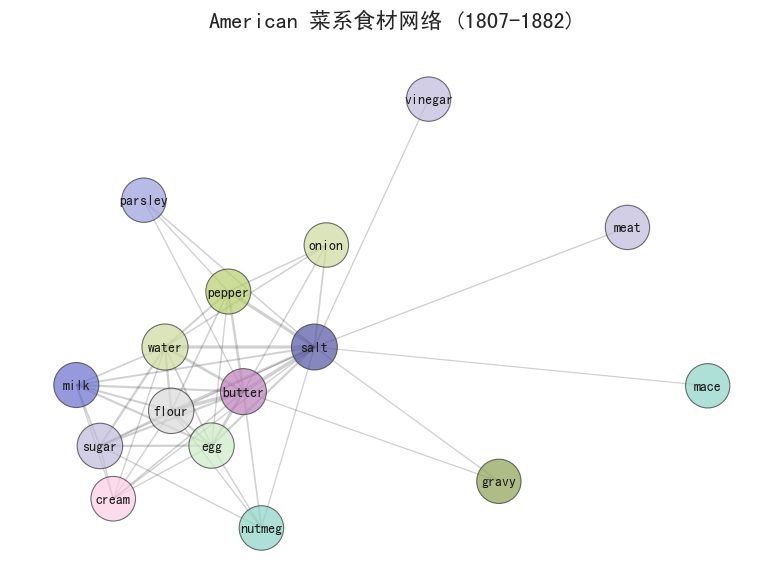

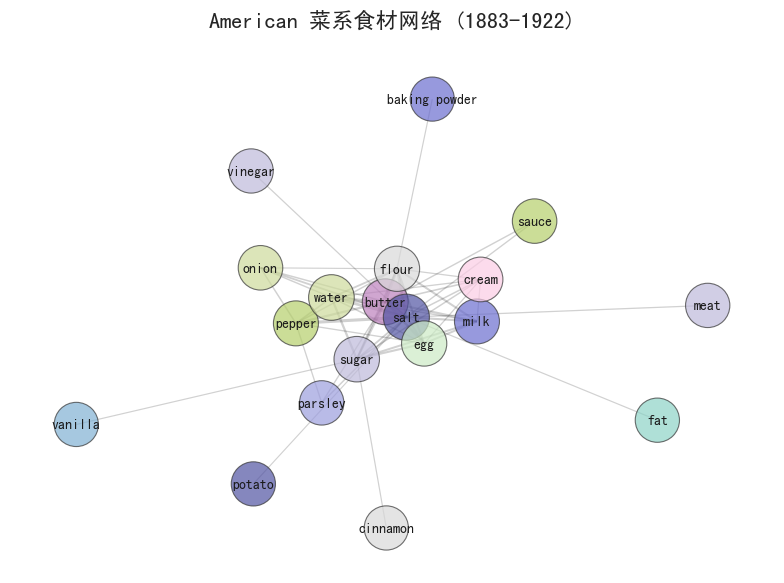

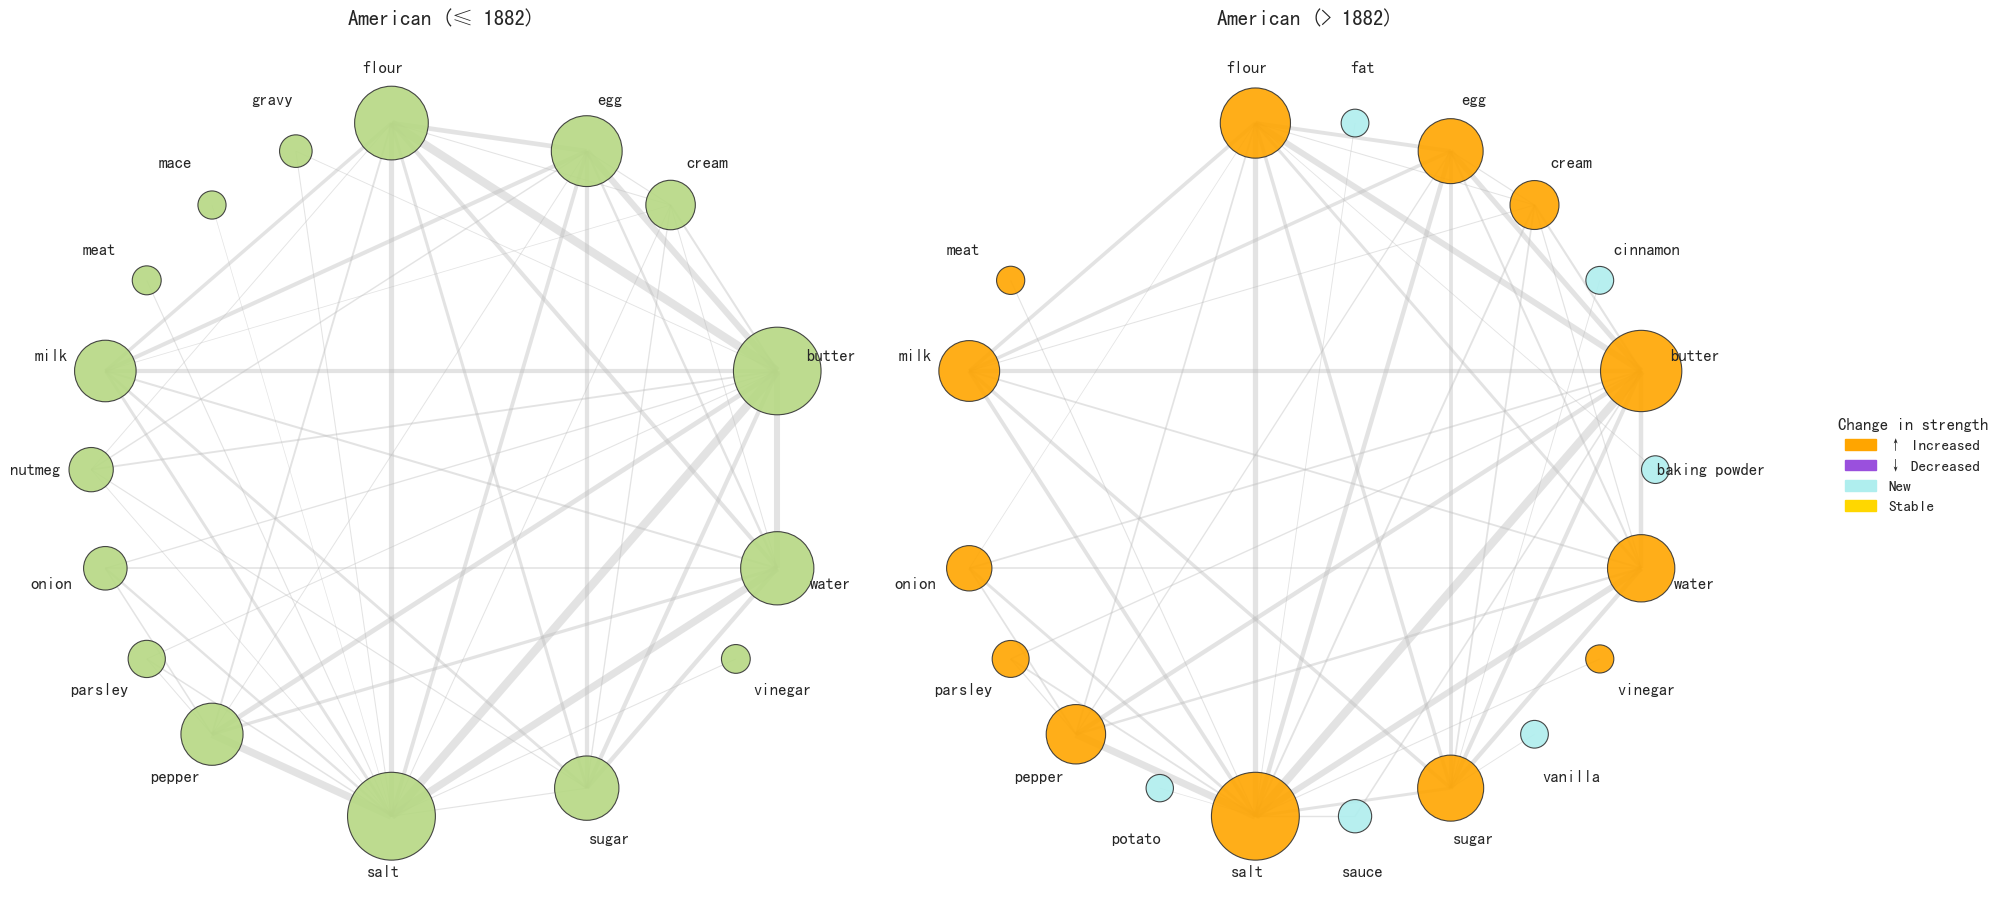

In [286]:
# 3.1 American
fig1_American, fig2_American, \
G1_American, G2_American, \
counts1_American, counts2_American = analyze_ingredients_by_period(
    df_books=df_books,
    df_recipes=df_recipes,
    subject_keyword="American",
    split_year=1882,      # 你的分界年份
    min_count=2,
    top_n=50
)
# 需要对比图时：
fig_American = plot_period_comparison(
    G1_American, counts1_American,
    G2_American, counts2_American,
    period1_label="American (≤ 1882)",
    period2_label="American (> 1882)",
    delta_threshold=0
    )

fig_American.savefig("American_1882_comparison.pdf",
                  format="pdf", bbox_inches="tight")

### 3.2 Asian

In [279]:
# 1. 拿到 Series
year_series = analyze_subject_years("Asian", df_books, show_details=False)


=== Analysis for Subject: Asian ===
Total number of books: 3
Year range: 1913.0 - 1922.0

Year Statistics:
Mean year  : 1916
Median year: 1914

Books per decade:
1910s: 2 books
1920s: 1 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/Asian_year_distribution.pdf



=== Analysis for Asian ===
Split year: 1916

G1_Asian (Before 1916): 2 books
Year range: 1913-1914

Books in G1:
1913 | The Oriental Cook Book
1914 | Chinese-Japanese Cook Book

G2_Asian (After 1916): 1 books
Year range: 1922-1922

Books in G2:
1922 | Foods of the Foreign-Born In Relation to Health

食谱数量统计:
第一时期食谱数量: 126
第二时期食谱数量: 105

生成第一时期的网络 (1913-1916)

--- create_ingredient_network 调试信息 ---
图信息:  20 个节点,  50 条边。
边权重范围: 9–40
节点频次范围: 10–85
网络密度: 0.2632
连通分量数量: 1, 最大分量节点数: 20
平均聚类系数: 0.5854
频次 Top-5: salt(85), water(51), syou(40), rice(39), onion(39)
--------------------------------------------------


生成第二时期的网络 (1917-1922)

--- create_ingredient_network 调试信息 ---
图信息:  21 个节点,  50 条边。
边权重范围: 7–43
节点频次范围: 8–63
网络密度: 0.2381
连通分量数量: 1, 最大分量节点数: 21
平均聚类系数: 0.6580
频次 Top-5: salt(63), water(56), egg(34), butter(29), pepper(28)
--------------------------------------------------



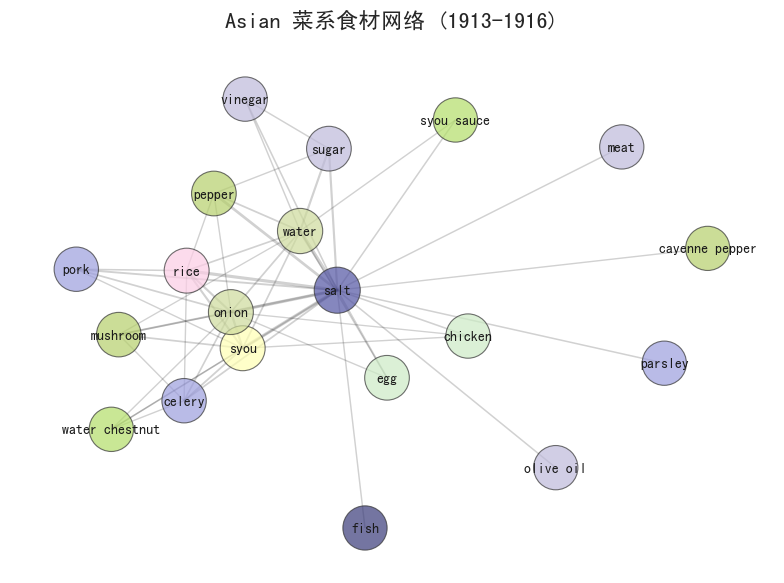

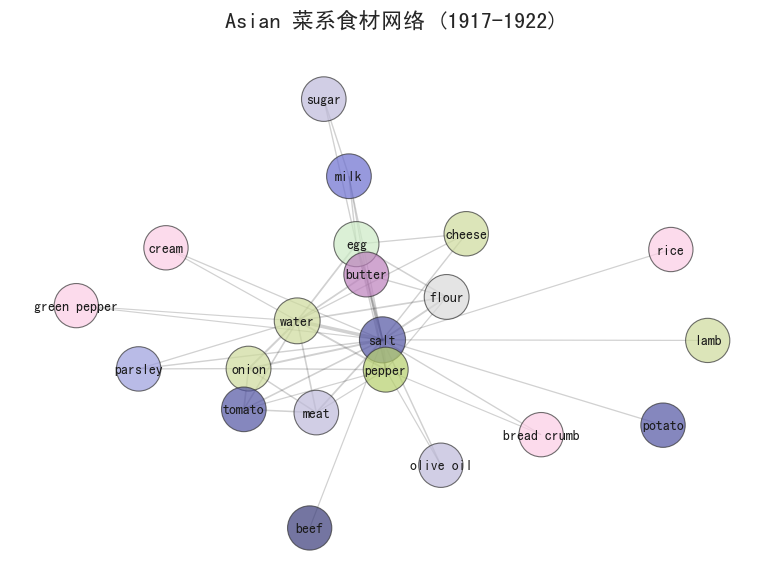

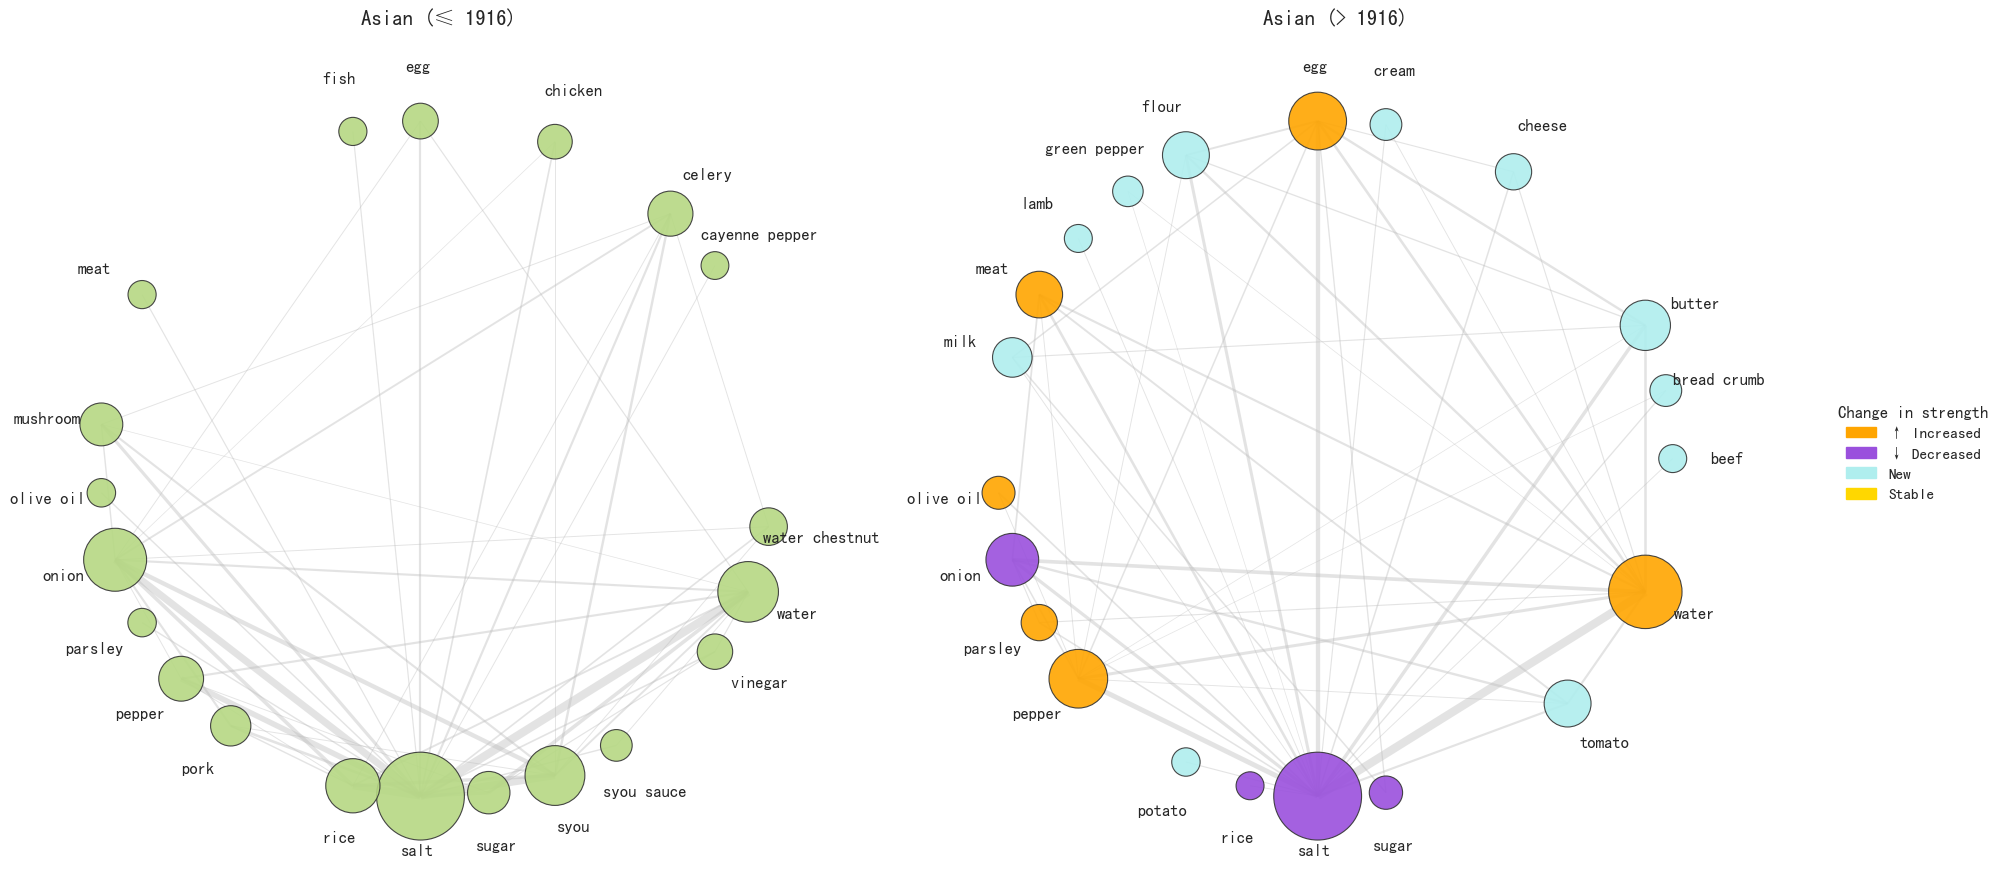

In [266]:
# 3.2 Asian
fig1_Asian, fig2_Asian, \
G1_Asian, G2_Asian, \
counts1_Asian, counts2_Asian = analyze_ingredients_by_period(
    df_books=df_books,
    df_recipes=df_recipes,
    subject_keyword="Asian",
    split_year=1916,
    min_count=2,
    top_n=50
)
fig_Asian = plot_period_comparison(
    G1_Asian, counts1_Asian,
    G2_Asian, counts2_Asian,
    period1_label="Asian (≤ 1916)",
    period2_label="Asian (> 1916)",
    delta_threshold=0
)
fig_Asian.savefig("Asian_1916_comparison.pdf",
                  format="pdf", bbox_inches="tight")

从网络里看出来，都是便宜的食材

1913 | The Oriental Cook Book：这本书想学习的是东方的烹饪方式，不是依赖于昂贵的食材

东方的烹饪经济实惠

### 3.3 French

In [280]:
year_distribution = analyze_subject_years("French", df_books, show_details=False)


=== Analysis for Subject: French ===
Total number of books: 6
Year range: 1868.0 - 1904.0

Year Statistics:
Mean year  : 1890
Median year: 1894

Books per decade:
1860s: 1 books
1880s: 1 books
1890s: 3 books
1900s: 1 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/French_year_distribution.pdf


移民潮是19世纪中后期，时间分散，让gpt再找个文献


=== Analysis for French ===
Split year: 1890

G1_French (Before 1890): 2 books
Year range: 1868-1885

Books in G1:
1868 | Hand-Book of Practical Cookery, for Ladies and Professional Cooks Containing The Whole Science and Art of Preparing Human Food
1885 | La Cuisine Creole

G2_French (After 1890): 4 books
Year range: 1893-1904

Books in G2:
1893 | La Cuisine Française French Cooking for Every Home Adapted to American Requirements
1894 | The Epicurean
1894 | The Epicurean A Complete Treatise of Analytical and Practical Studies on The Culinary Art, Including
1904 | Cooking in old Créole days La cuisine créole à l'usage des petits ménages

食谱数量统计:
第一时期食谱数量: 1236
第二时期食谱数量: 2157

生成第一时期的网络 (1868-1890)

--- create_ingredient_network 调试信息 ---
图信息:  16 个节点,  50 条边。
边权重范围: 50–264
节点频次范围: 61–474
网络密度: 0.4167
连通分量数量: 1, 最大分量节点数: 16
平均聚类系数: 0.7535
频次 Top-5: butter(474), water(470), salt(446), sugar(342), flour(330)
--------------------------------------------------


生成第二时期的网络 (1891-1904)

--- cr

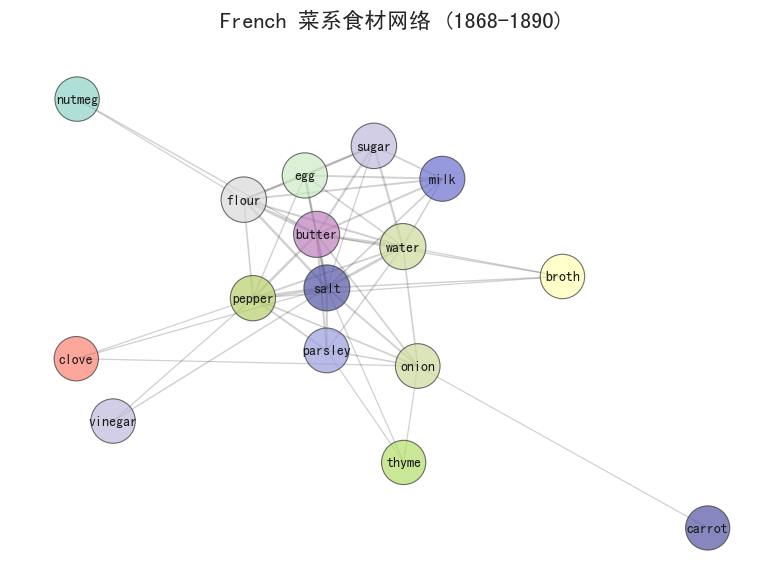

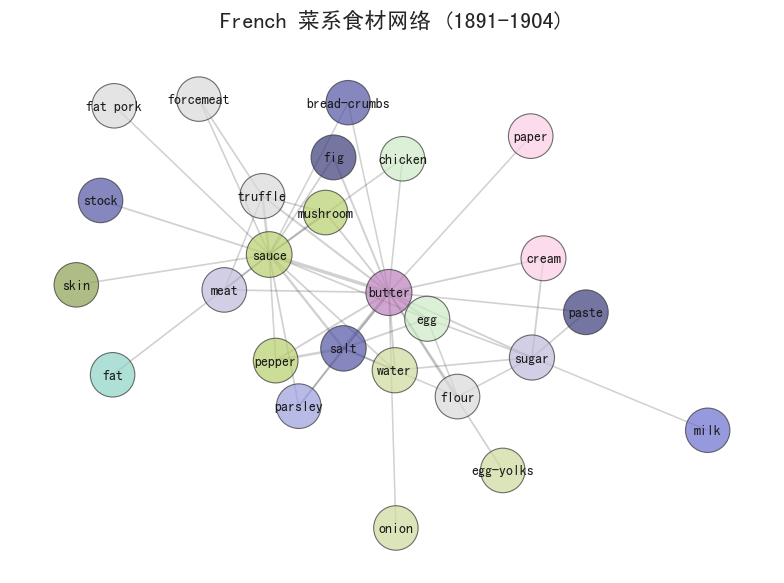

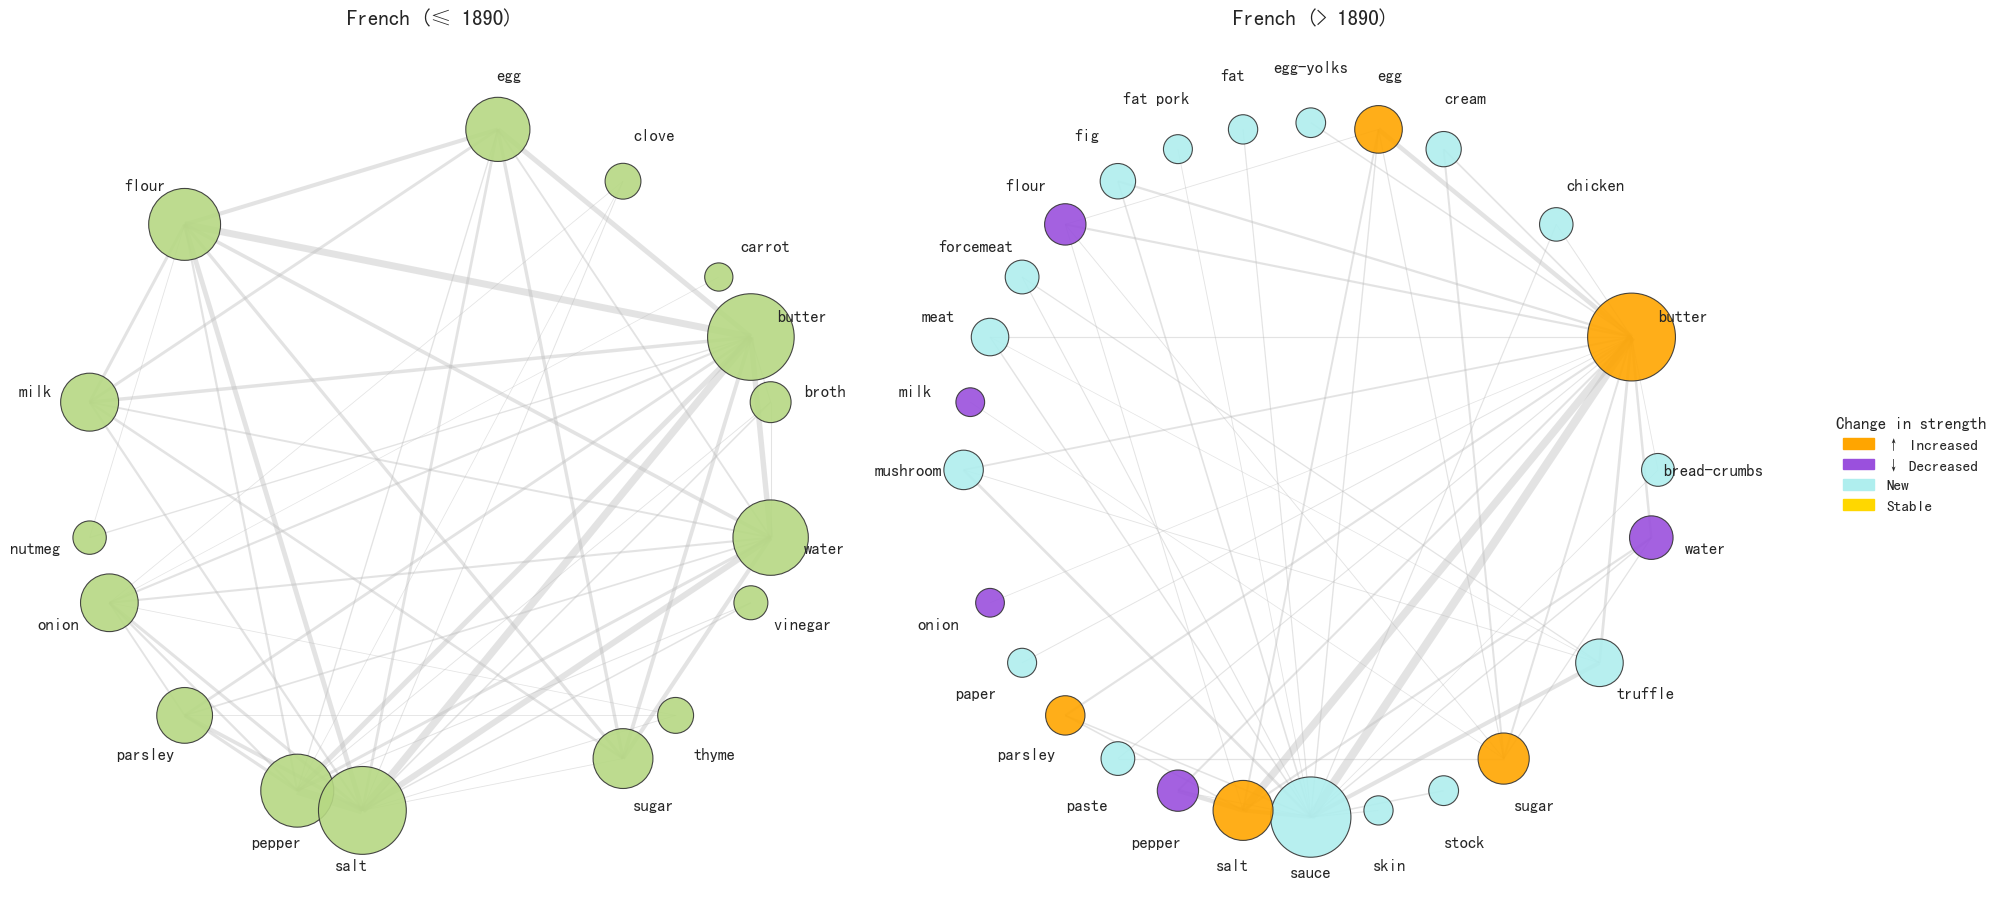

In [267]:
# 3.3 French
fig1_French, fig2_French, \
G1_French, G2_French, \
counts1_French, counts2_French = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="French",
    split_year=1890,
    min_count=2,
    top_n=50
)
fig_French = plot_period_comparison(
    G1_French, counts1_French,
    G2_French, counts2_French,
    period1_label="French (≤ 1890)",
    period2_label="French (> 1890)",
    delta_threshold=0
)
fig_French.savefig("French_1890_comparison.pdf",
                  format="pdf", bbox_inches="tight")

1893 | La Cuisine Française French Cooking for Every Home Adapted to American Requirements, 这本书的目的是让法国和美国的饮食结合 Making a Franco-American Culinary Encyclopedia

1. 烹制，装饰，上菜：学习到了法餐的精致
2.引入了新的dish：对应食材种类的大量增加

### 3.4 Creole（不做了）

In [281]:
year_distribution = analyze_subject_years("Creole", df_books, show_details=False)


=== Analysis for Subject: Creole ===
Total number of books: 2
Year range: 1885.0 - 1904.0

Year Statistics:
Mean year  : 1894
Median year: 1894

Books per decade:
1880s: 1 books
1900s: 1 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/Creole_year_distribution.pdf



=== Analysis for Creole ===
Split year: 1890

G1_Creole (Before 1890): 1 books
Year range: 1885-1885

Books in G1:
1885 | La Cuisine Creole

G2_Creole (After 1890): 1 books
Year range: 1904-1904

Books in G2:
1904 | Cooking in old Créole days La cuisine créole à l'usage des petits ménages

食谱数量统计:
第一时期食谱数量: 715
第二时期食谱数量: 205

生成第一时期的网络 (1885-1890)

--- create_ingredient_network 调试信息 ---
图信息:  15 个节点,  50 条边。
边权重范围: 28–146
节点频次范围: 44–286
网络密度: 0.4762
连通分量数量: 1, 最大分量节点数: 15
平均聚类系数: 0.8149
频次 Top-5: water(286), butter(284), salt(263), sugar(237), flour(230)
--------------------------------------------------


生成第二时期的网络 (1891-1904)

--- create_ingredient_network 调试信息 ---
图信息:  17 个节点,  50 条边。
边权重范围: 11–54
节点频次范围: 14–108
网络密度: 0.3676
连通分量数量: 1, 最大分量节点数: 17
平均聚类系数: 0.6615
频次 Top-5: salt(108), butter(92), water(78), flour(64), egg(54)
--------------------------------------------------



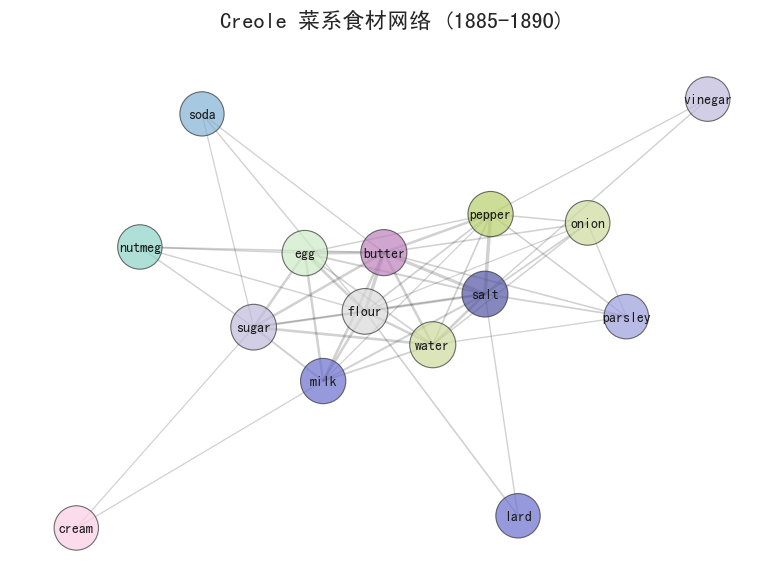

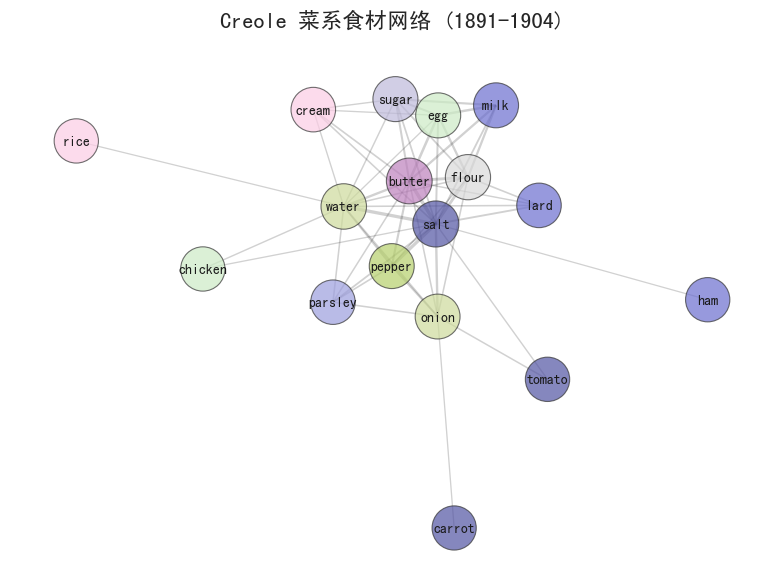

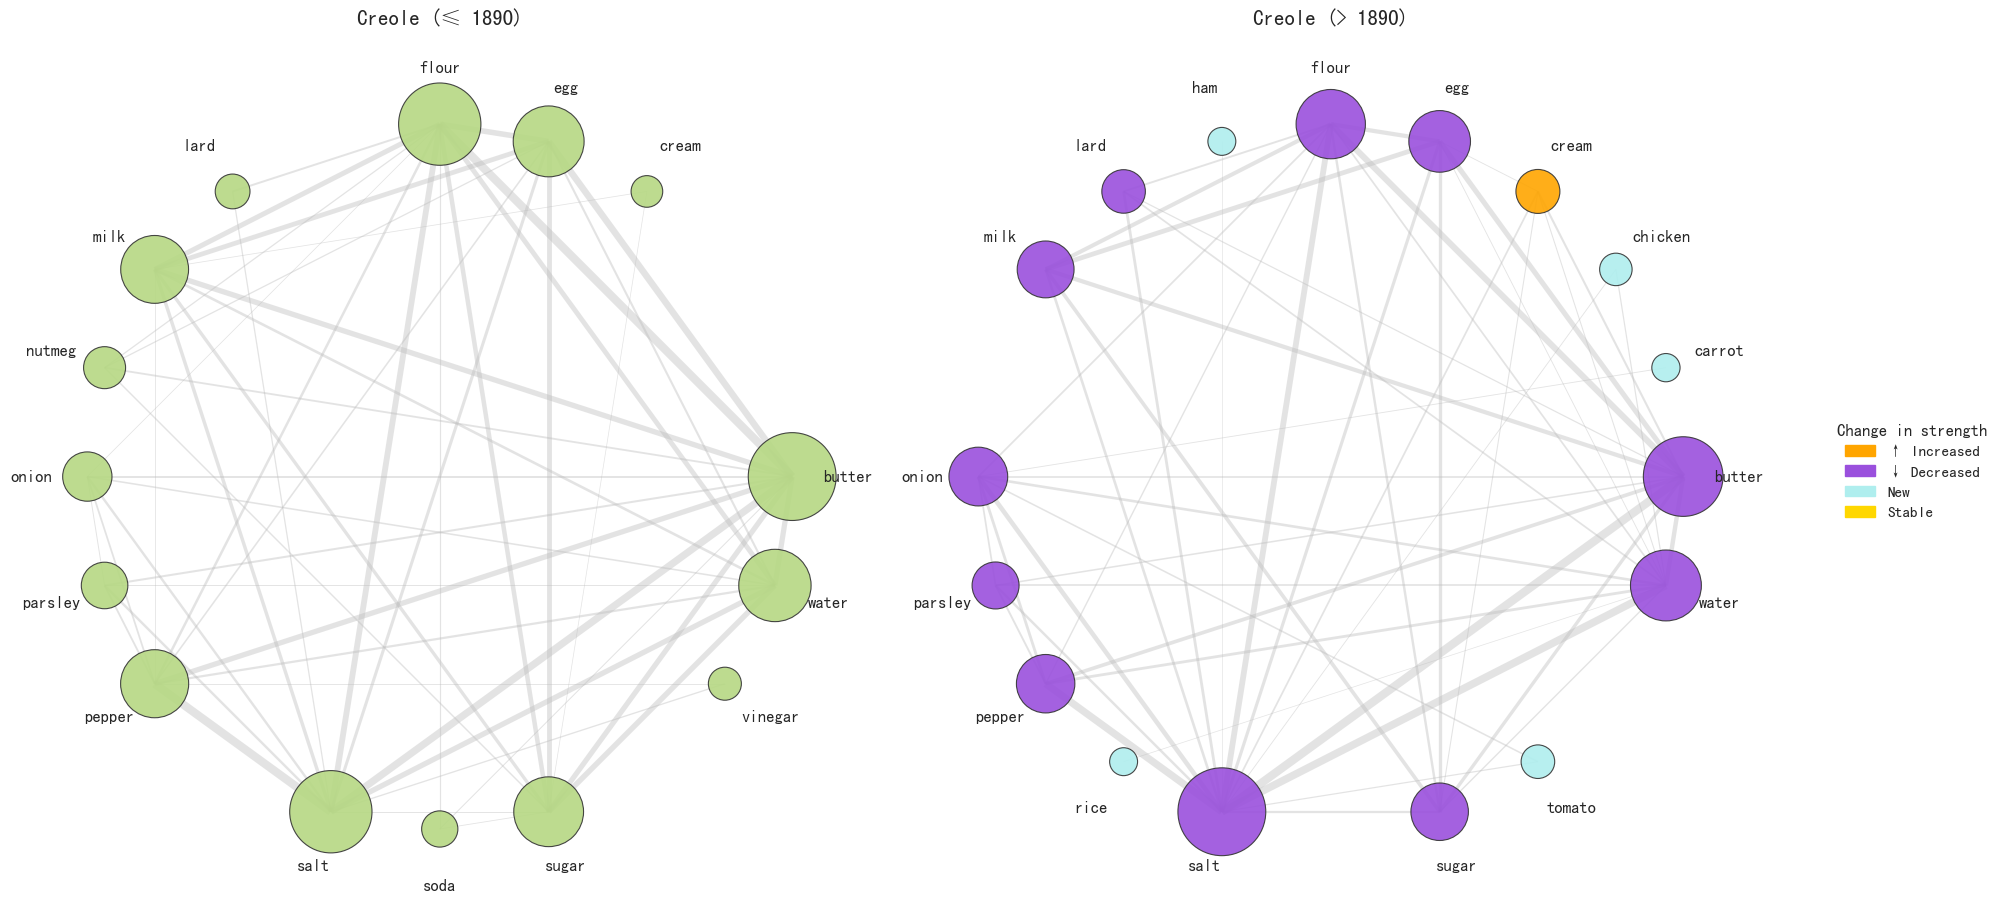

In [272]:
# 3.4 Creole
fig1_Creole, fig2_Creole, \
G1_Creole, G2_Creole, \
counts1_Creole, counts2_Creole = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="Creole",
    split_year=1890,
    min_count=2,
    top_n=50
)
fig_Creole = plot_period_comparison(
    G1_Creole, counts1_Creole,
    G2_Creole, counts2_Creole,
    period1_label="Creole (≤ 1890)",
    period2_label="Creole (> 1890)",
    delta_threshold=0
)
fig_Creole.savefig("Creole_1890_comparison.pdf",
                  format="pdf", bbox_inches="tight")

### 3.5 Italian

In [282]:
year_distribution = analyze_subject_years("Italian", df_books, show_details=False)


=== Analysis for Subject: Italian ===
Total number of books: 2
Year range: 1919.0 - 1922.0

Year Statistics:
Mean year  : 1920
Median year: 1920

Books per decade:
1910s: 1 books
1920s: 1 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/Italian_year_distribution.pdf



=== Analysis for Italian ===
Split year: 1920

G1_Italian (Before 1920): 1 books
Year range: 1919-1919

Books in G1:
1919 | The Italian Cook Book: The Art of Eating Well

G2_Italian (After 1920): 1 books
Year range: 1922-1922

Books in G2:
1922 | Foods of the Foreign-Born In Relation to Health

食谱数量统计:
第一时期食谱数量: 220
第二时期食谱数量: 105

生成第一时期的网络 (1919-1920)

--- create_ingredient_network 调试信息 ---
图信息:  15 个节点,  50 条边。
边权重范围: 21–96
节点频次范围: 27–139
网络密度: 0.4762
连通分量数量: 1, 最大分量节点数: 15
平均聚类系数: 0.6957
频次 Top-5: salt(139), butter(121), pepper(100), water(96), flour(69)
--------------------------------------------------


生成第二时期的网络 (1921-1922)

--- create_ingredient_network 调试信息 ---
图信息:  21 个节点,  50 条边。
边权重范围: 7–43
节点频次范围: 8–63
网络密度: 0.2381
连通分量数量: 1, 最大分量节点数: 21
平均聚类系数: 0.6580
频次 Top-5: salt(63), water(56), egg(34), butter(29), pepper(28)
--------------------------------------------------



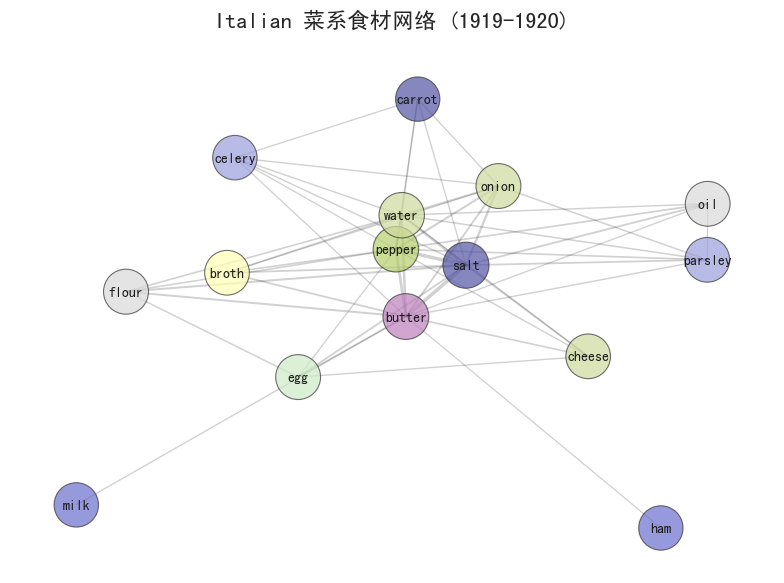

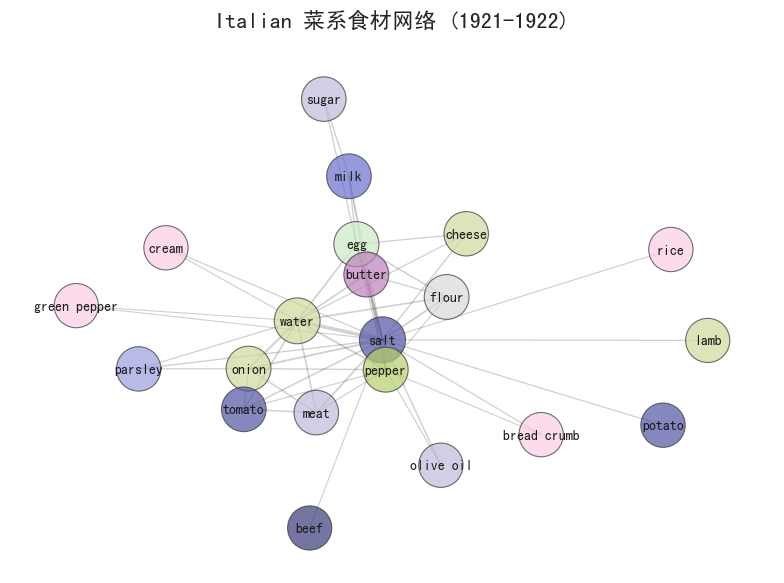

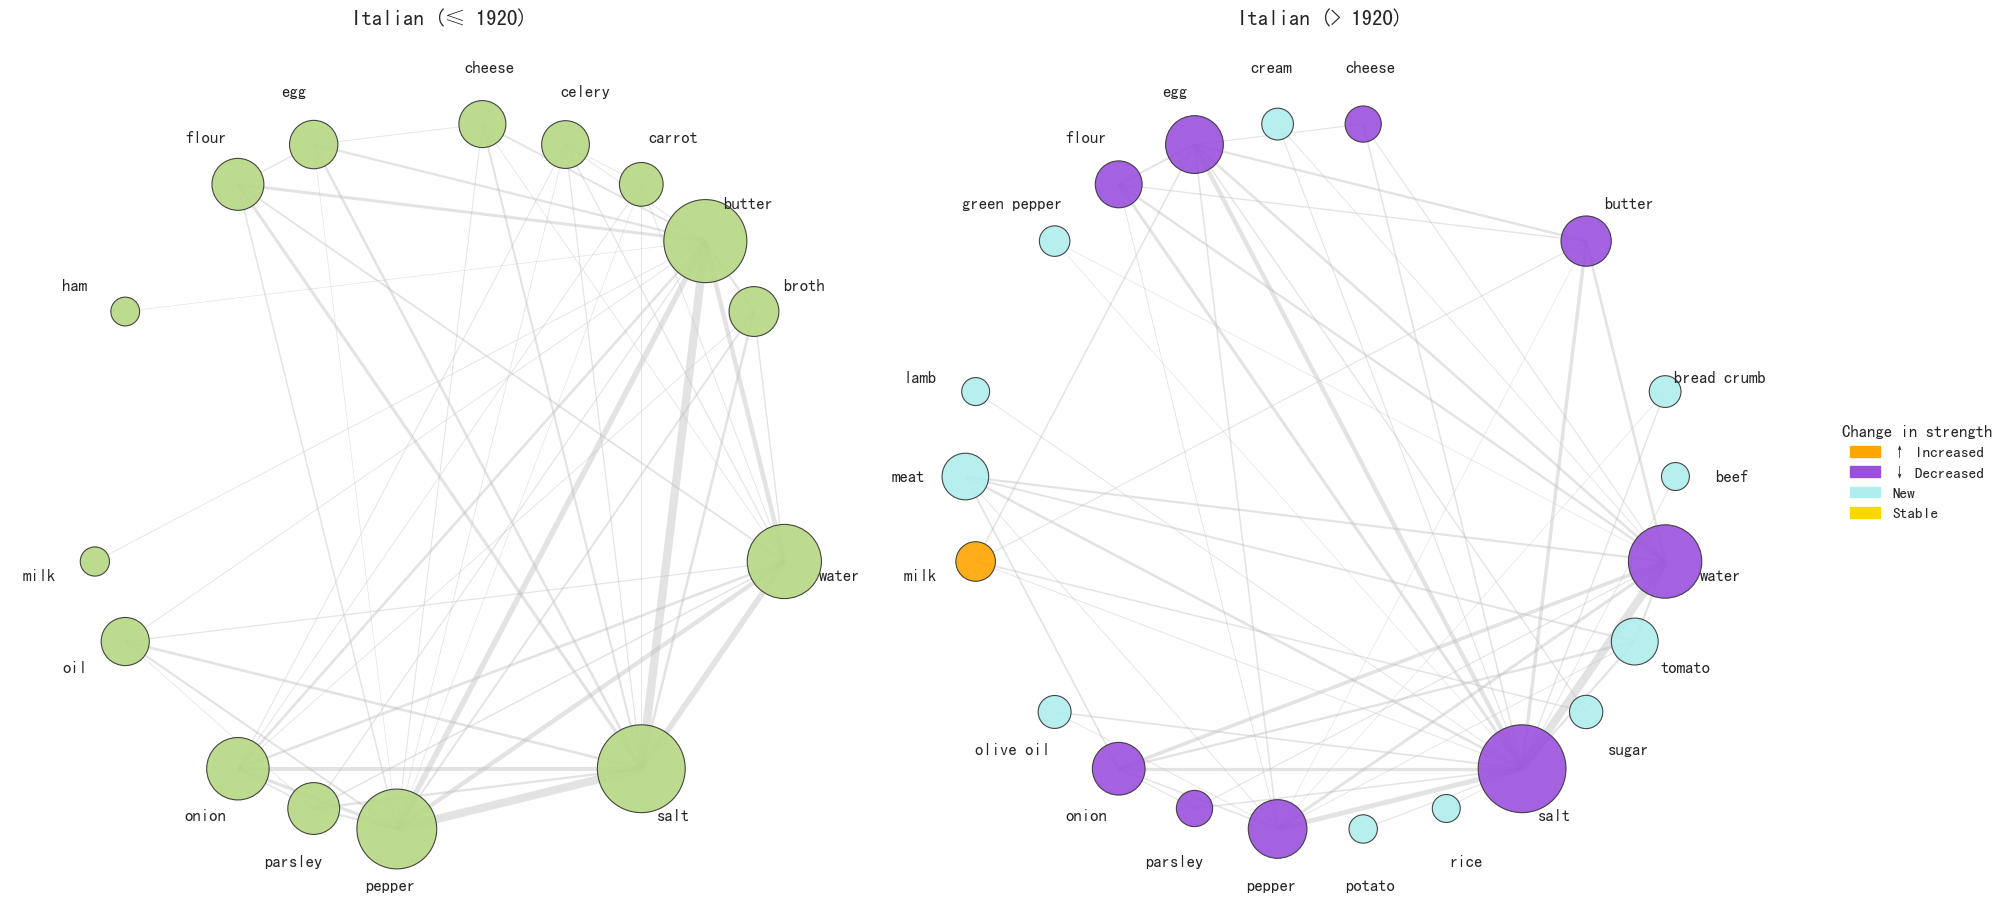

In [268]:
# 3.5 Italian
fig1_Italian, fig2_Italian, \
G1_Italian, G2_Italian, \
counts1_Italian, counts2_Italian = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="Italian",
    split_year=1920,
    min_count=2,
    top_n=50
)
fig_Italian = plot_period_comparison(
    G1_Italian, counts1_Italian,
    G2_Italian, counts2_Italian,
    period1_label="Italian (≤ 1920)",
    period2_label="Italian (> 1920)",
    delta_threshold=0
)
fig_Italian.savefig("Italian_1920_comparison.pdf",
                  format="pdf", bbox_inches="tight")

1919: 因为一站的影响，美国的家庭主妇开始节俭，战后大家开始节俭，注重经济实惠--找找历史文献解释一下，意大利菜很便宜实惠PREFACE One of the beneficial results of the Great War has been the teaching of thrift to the American housewife. For patriotic reasons and for reasons of economy, more attention has been bestowed upon the preparing and cooking of food that is to be at once palatable, nourishing and economical. In the Italian cuisine we find in the highest degree these three qualities. That it is palatable, all those who have partaken of food in an Italian trattoria It has therefore been thought that a book of PRACTICAL RECIPES OF THE ITALIAN CUISINE could be offered to the American public with hope of success. It is not a pretentious book, and the recipes have been made as clear and simple as possible. Some of the dishes described are not peculiar to Italy. All, however, are representative of the Cucina Casalinga

1922 | Foods of the Foreign-Born In Relation to Health---会不会找找文献说这个跟健康有关系

### 3.6 German（不做了）

In [283]:
year_distribution = analyze_subject_years("German", df_books, show_details=False)


=== Analysis for Subject: German ===
Total number of books: 2
Year range: 1897.0 - 1915.0

Year Statistics:
Mean year  : 1906
Median year: 1906

Books per decade:
1890s: 1 books
1910s: 1 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/German_year_distribution.pdf



=== Analysis for German ===
Split year: 1900

G1_German (Before 1900): 1 books
Year range: 1897-1897

Books in G1:
1897 | Henriette Davidis' Practical Cook Book Compiled For The United States From The Thirty-Fifth German Edition

G2_German (After 1900): 1 books
Year range: 1915-1915

Books in G2:
1915 | Mary at the Farm and Book of Recipes

食谱数量统计:
第一时期食谱数量: 1611
第二时期食谱数量: 554

生成第一时期的网络 (1897-1900)

--- create_ingredient_network 调试信息 ---
图信息:  22 个节点,  50 条边。
边权重范围: 111–463
节点频次范围: 139–815
网络密度: 0.2165
连通分量数量: 1, 最大分量节点数: 22
平均聚类系数: 0.5519
频次 Top-5: butter(815), salt(724), sugar(697), water(693), egg(525)
--------------------------------------------------


生成第二时期的网络 (1901-1915)

--- create_ingredient_network 调试信息 ---
图信息:  13 个节点,  50 条边。
边权重范围: 48–221
节点频次范围: 73–320
网络密度: 0.6410
连通分量数量: 1, 最大分量节点数: 13
平均聚类系数: 0.8550
频次 Top-5: sugar(320), butter(304), flour(304), salt(270), water(259)
--------------------------------------------------



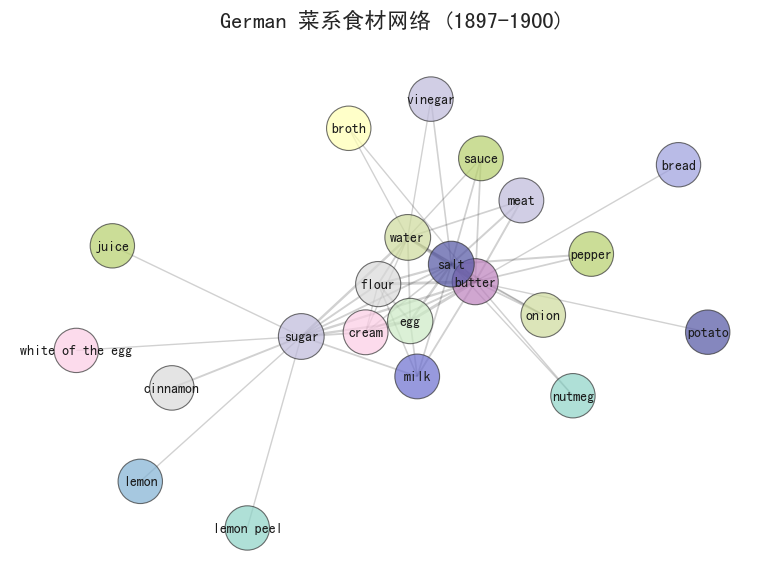

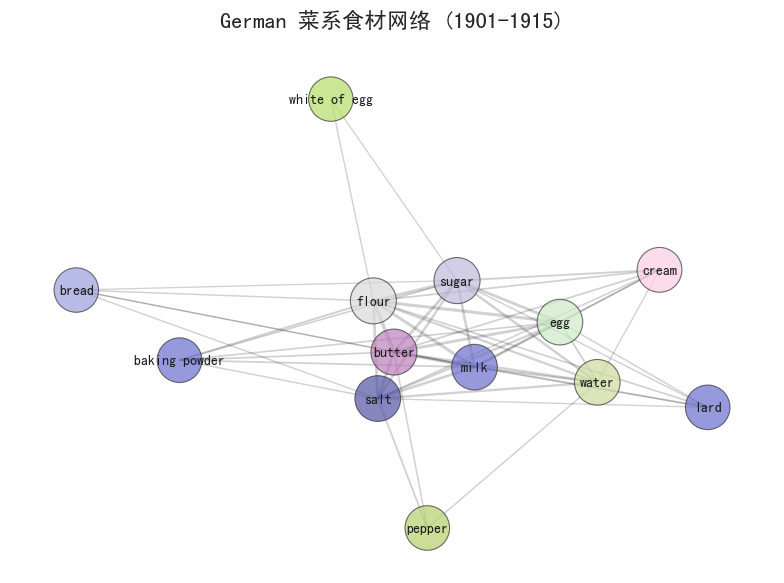

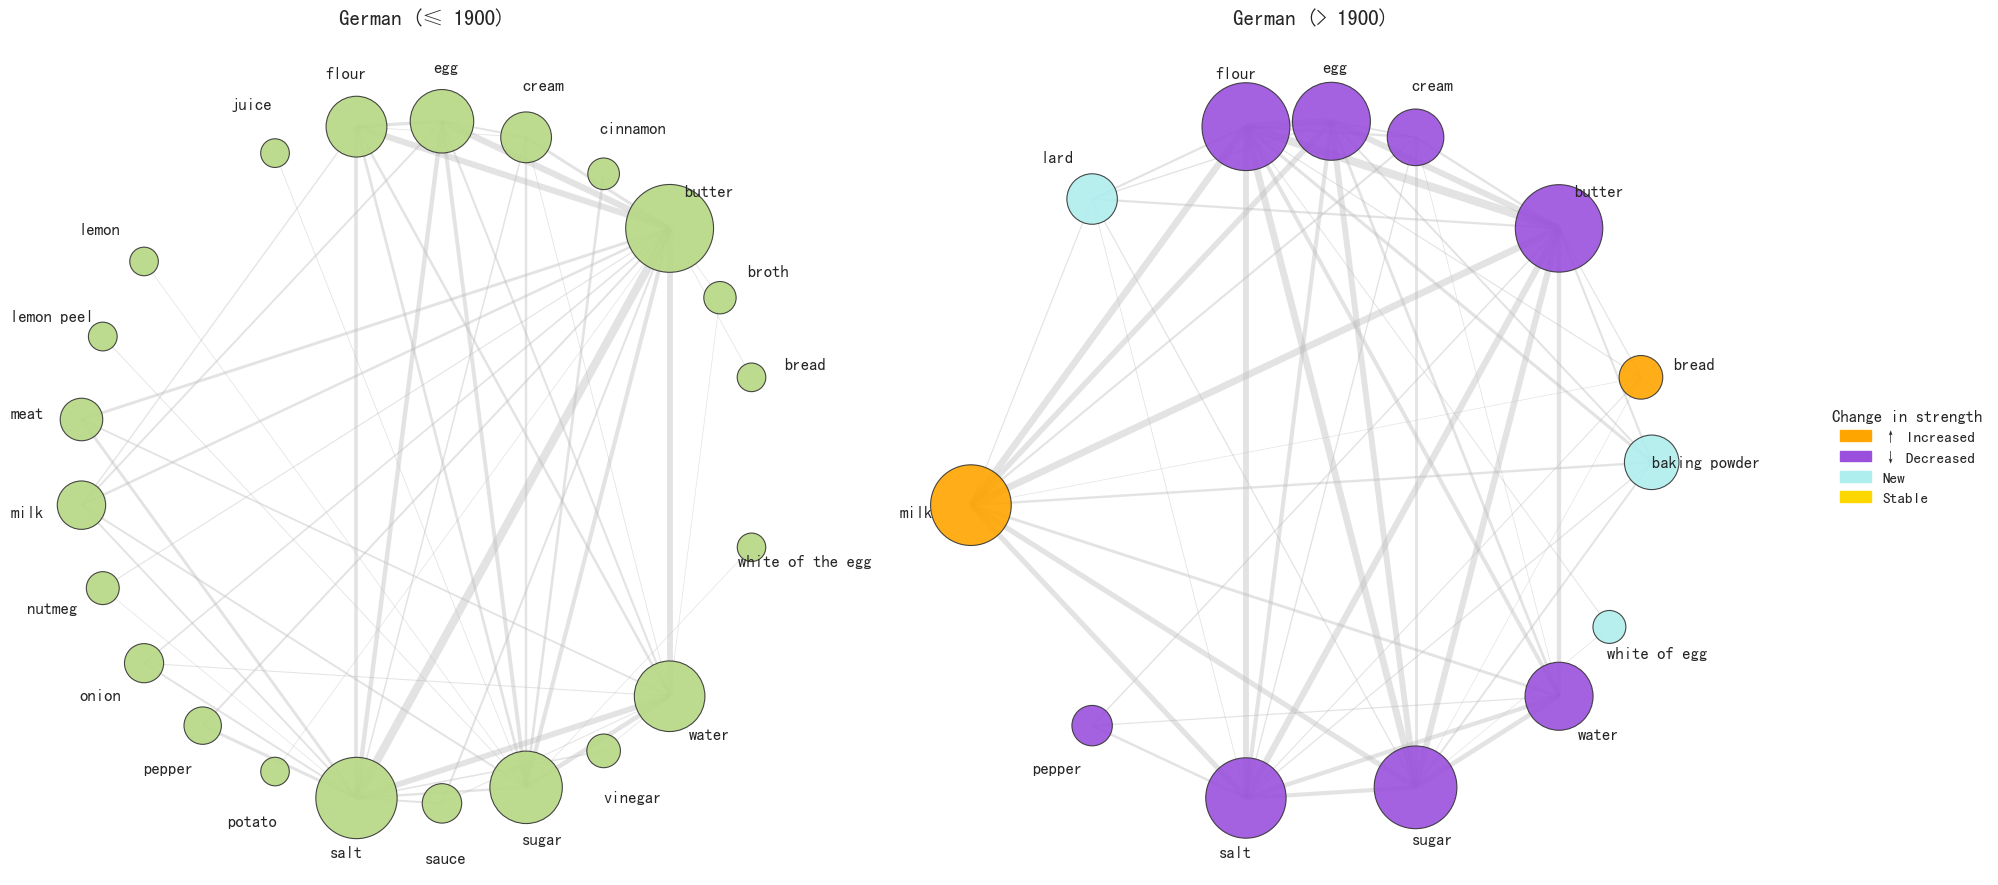

In [271]:
fig1_German, fig2_German, \
G1_German, G2_German, \
counts1_German, counts2_German = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="German",
    split_year=1900,
    min_count=2,
    top_n=50
)
fig_German = plot_period_comparison(
    G1_German, counts1_German,
    G2_German, counts2_German,
    period1_label="German (≤ 1900)",
    period2_label="German (> 1900)",
    delta_threshold=0
)
fig_German.savefig("German_1900_comparison.pdf",
                  format="pdf", bbox_inches="tight")

### 3.7 LatinAmerican（不做了）

In [284]:
year_distribution = analyze_subject_years("LatinAmerican", df_books, show_details=False)


=== Analysis for Subject: LatinAmerican ===
Total number of books: 2
Year range: 1905.0 - 1922.0

Year Statistics:
Mean year  : 1914
Median year: 1914

Books per decade:
1900s: 1 books
1920s: 1 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/LatinAmerican_year_distribution.pdf



=== Analysis for LatinAmerican ===
Split year: 1920

G1_LatinAmerican (Before 1920): 1 books
Year range: 1905-1905

Books in G1:
1905 | The Times Cook Book - No 2

G2_LatinAmerican (After 1920): 1 books
Year range: 1922-1922

Books in G2:
1922 | Foods of the Foreign-Born In Relation to Health

食谱数量统计:
第一时期食谱数量: 963
第二时期食谱数量: 105

生成第一时期的网络 (1905-1920)

--- create_ingredient_network 调试信息 ---
图信息:  20 个节点,  50 条边。
边权重范围: 52–218
节点频次范围: 63–453
网络密度: 0.2632
连通分量数量: 1, 最大分量节点数: 20
平均聚类系数: 0.5907
频次 Top-5: salt(453), water(451), sugar(432), butter(394), flour(292)
--------------------------------------------------


生成第二时期的网络 (1921-1922)

--- create_ingredient_network 调试信息 ---
图信息:  21 个节点,  50 条边。
边权重范围: 7–43
节点频次范围: 8–63
网络密度: 0.2381
连通分量数量: 1, 最大分量节点数: 21
平均聚类系数: 0.6580
频次 Top-5: salt(63), water(56), egg(34), butter(29), pepper(28)
--------------------------------------------------



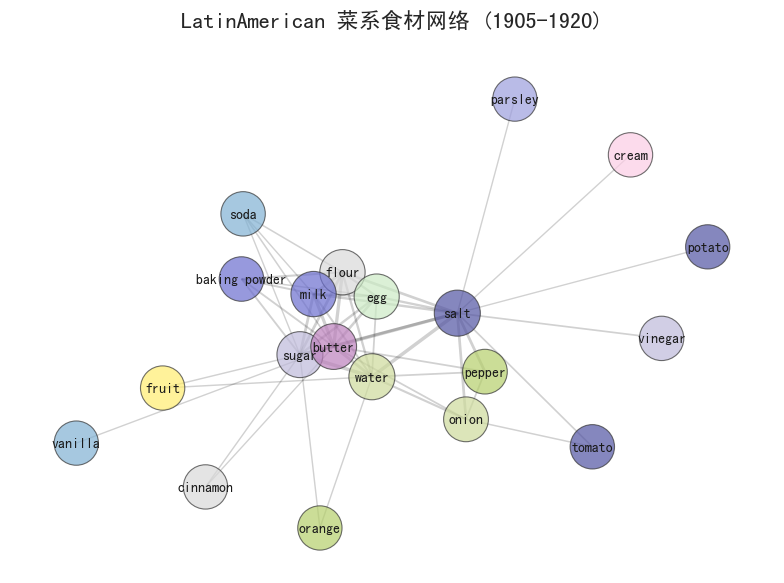

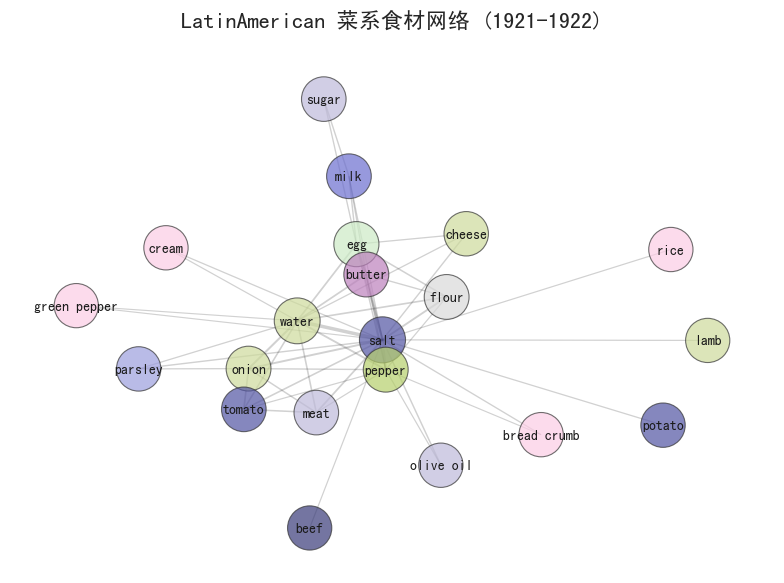

In [260]:
fig1_LatinAmerican, fig2_LatinAmerican, \
G1_LatinAmerican, G2_LatinAmerican, \
counts1_LatinAmerican, counts2_LatinAmerican = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="LatinAmerican",
    split_year=1920,
    min_count=2, top_n=50
)


=== Analysis for LatinAmerican ===
Split year: 1920

G1_LatinAmerican (Before 1920): 1 books
Year range: 1905-1905

Books in G1:
1905 | The Times Cook Book - No 2

G2_LatinAmerican (After 1920): 1 books
Year range: 1922-1922

Books in G2:
1922 | Foods of the Foreign-Born In Relation to Health

食谱数量统计:
第一时期食谱数量: 963
第二时期食谱数量: 105

生成第一时期的网络 (1905-1920)

--- create_ingredient_network 调试信息 ---
图信息:  20 个节点,  50 条边。
边权重范围: 52–218
节点频次范围: 63–453
网络密度: 0.2632
连通分量数量: 1, 最大分量节点数: 20
平均聚类系数: 0.5907
频次 Top-5: salt(453), water(451), sugar(432), butter(394), flour(292)
--------------------------------------------------


生成第二时期的网络 (1921-1922)

--- create_ingredient_network 调试信息 ---
图信息:  21 个节点,  50 条边。
边权重范围: 7–43
节点频次范围: 8–63
网络密度: 0.2381
连通分量数量: 1, 最大分量节点数: 21
平均聚类系数: 0.6580
频次 Top-5: salt(63), water(56), egg(34), butter(29), pepper(28)
--------------------------------------------------



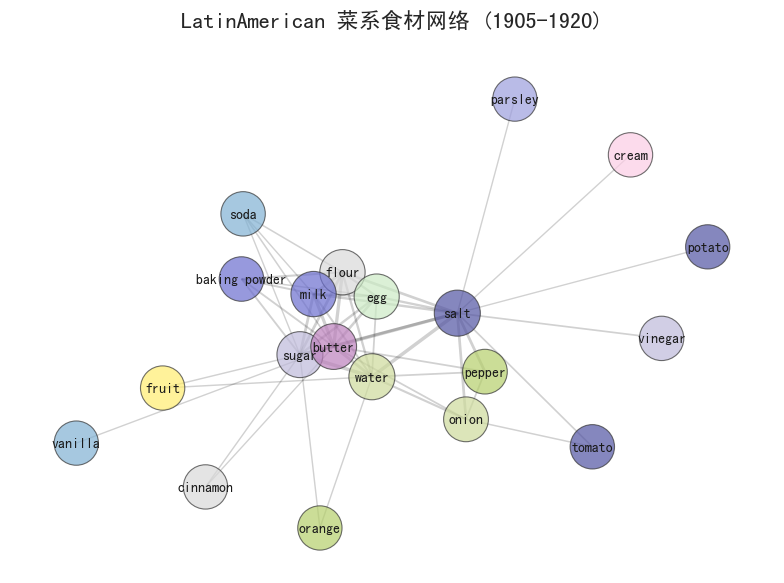

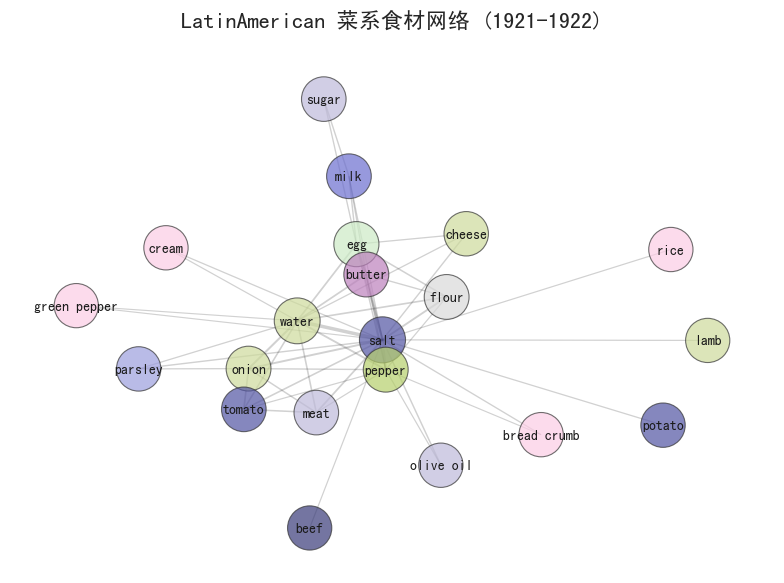

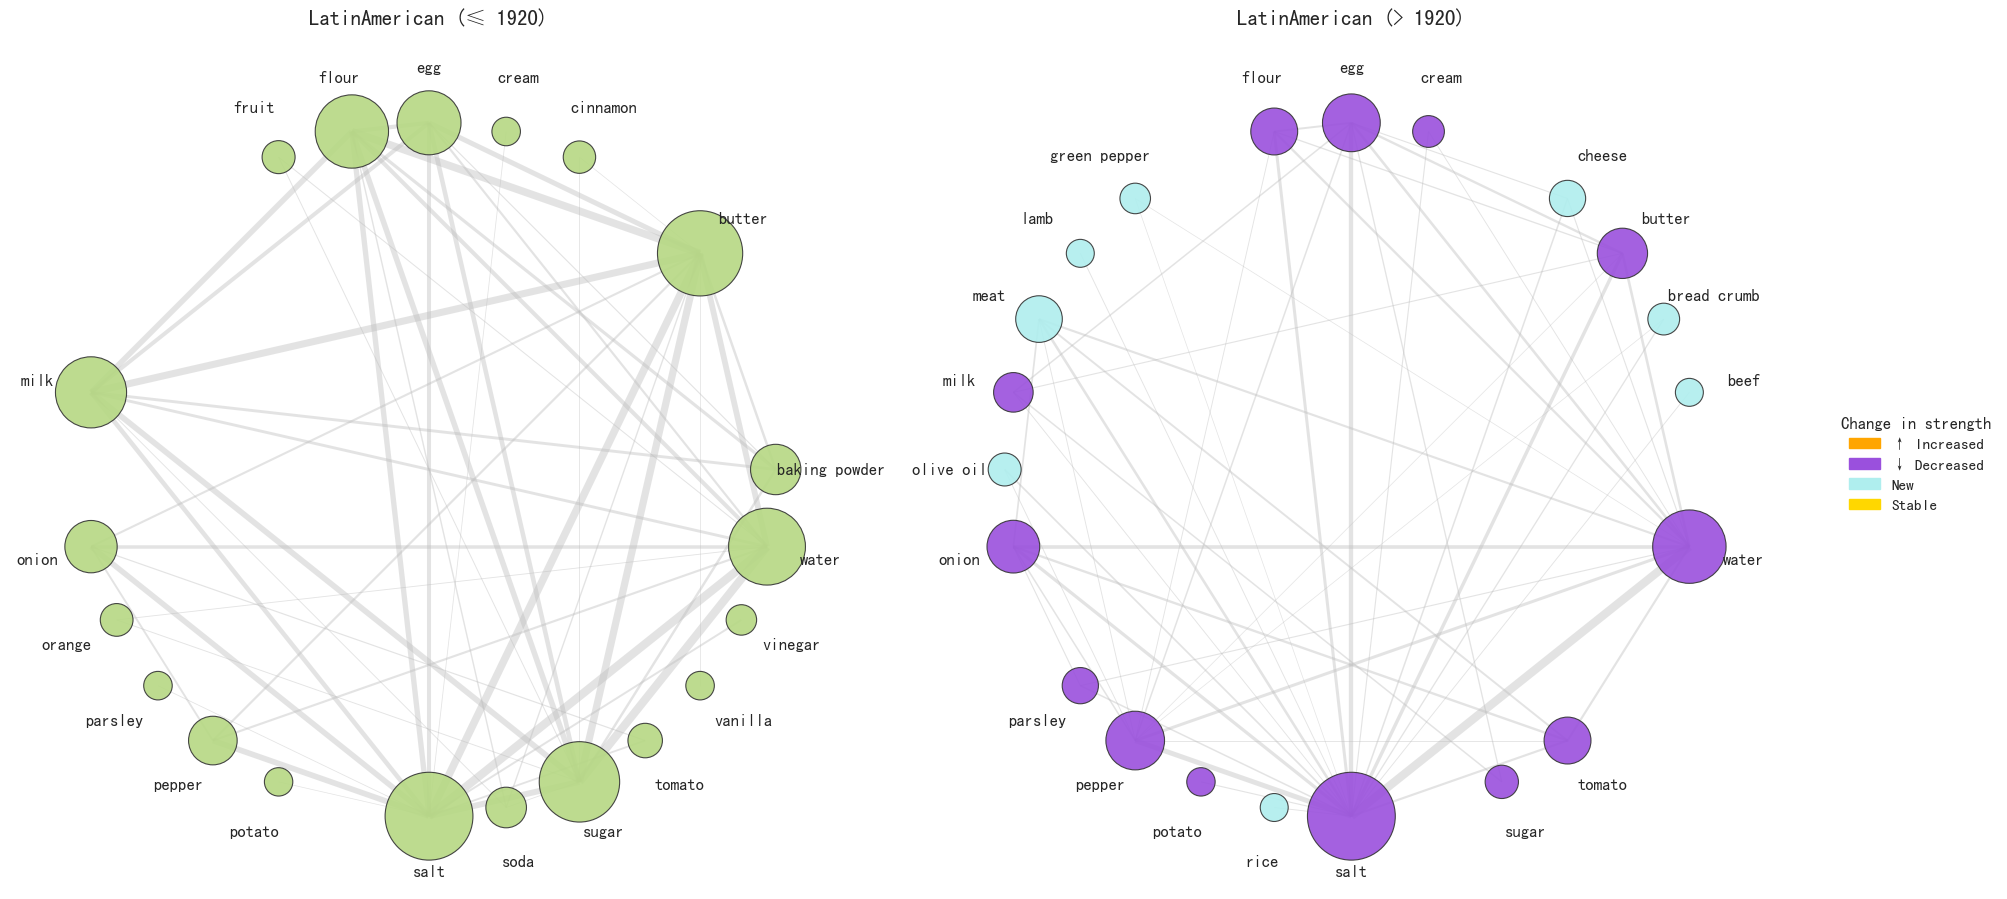

In [270]:
fig1_LatinAmerican, fig2_LatinAmerican, \
G1_LatinAmerican, G2_LatinAmerican, \
counts1_LatinAmerican, counts2_LatinAmerican = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="LatinAmerican",
    split_year=1920,
    min_count=2,
    top_n=50
)
fig_LatinAmerican = plot_period_comparison(
    G1_LatinAmerican, counts1_LatinAmerican,
    G2_LatinAmerican, counts2_LatinAmerican,
    period1_label="LatinAmerican (≤ 1920)",
    period2_label="LatinAmerican (> 1920)",
    delta_threshold=0
)
fig_LatinAmerican.savefig("LatinAmerican_1920_comparison.pdf",
                  format="pdf", bbox_inches="tight")


### 3.8 AfricanAmerican

In [285]:
year_distribution = analyze_subject_years("AfricanAmerican", df_books, show_details=False)


=== Analysis for Subject: AfricanAmerican ===
Total number of books: 8
Year range: 1827.0 - 1917.0

Year Statistics:
Mean year  : 1886
Median year: 1894

Books per decade:
1820s: 1 books
1840s: 1 books
1880s: 2 books
1900s: 1 books
1910s: 3 books

PDF saved to: /Users/liuyiwei/python/American-Cuisine-Immigration/AfricanAmerican_year_distribution.pdf



=== Analysis for AfricanAmerican ===
Split year: 1900

G1_AfricanAmerican (Before 1900): 4 books
Year range: 1827-1885

Books in G1:
1827 | The House Servant's Directory
1848 | Hotel Keepers, Head Waiters, and Housekeepers' Guide
1881 | What Mrs Fisher Knows about Old Southern Cooking, Soups, Pickles, Preserves, etc
1885 | La Cuisine Creole

G2_AfricanAmerican (After 1900): 4 books
Year range: 1904-1917

Books in G2:
1904 | Cooking in old Créole days La cuisine créole à l'usage des petits ménages
1911 | Good Things to Eat, As Suggested By Rufus
1913 | Dishes & Beverages of the Old South
1917 | The Ideal Bartender

食谱数量统计:
第一时期食谱数量: 1000
第二时期食谱数量: 1183

生成第一时期的网络 (1827-1900)

--- create_ingredient_network 调试信息 ---
图信息:  16 个节点,  50 条边。
边权重范围: 37–212
节点频次范围: 52–395
网络密度: 0.4167
连通分量数量: 1, 最大分量节点数: 16
平均聚类系数: 0.7099
频次 Top-5: butter(395), water(395), salt(381), sugar(313), flour(308)
--------------------------------------------------


生成第二时期的网络 (1901-1917)

--- create_ingredient_network

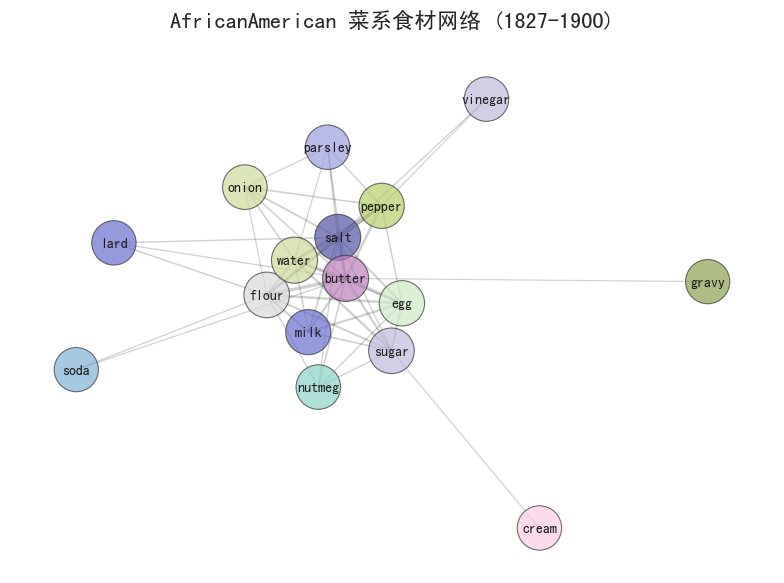

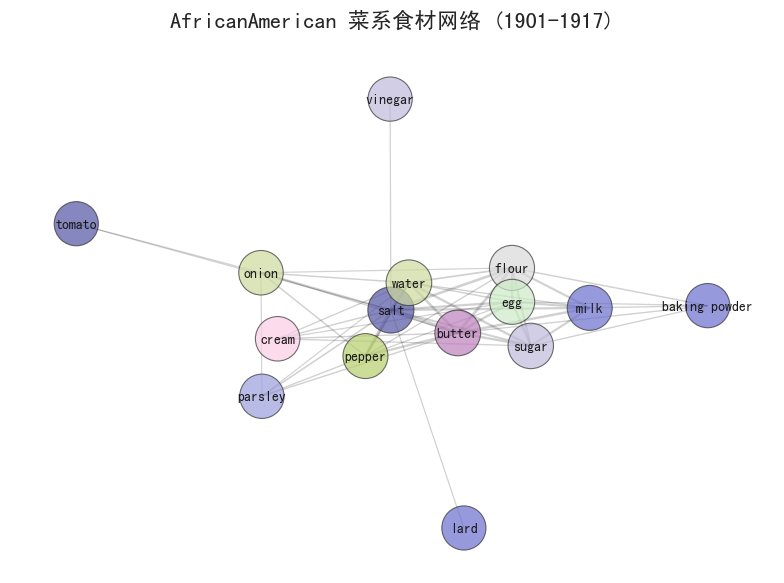

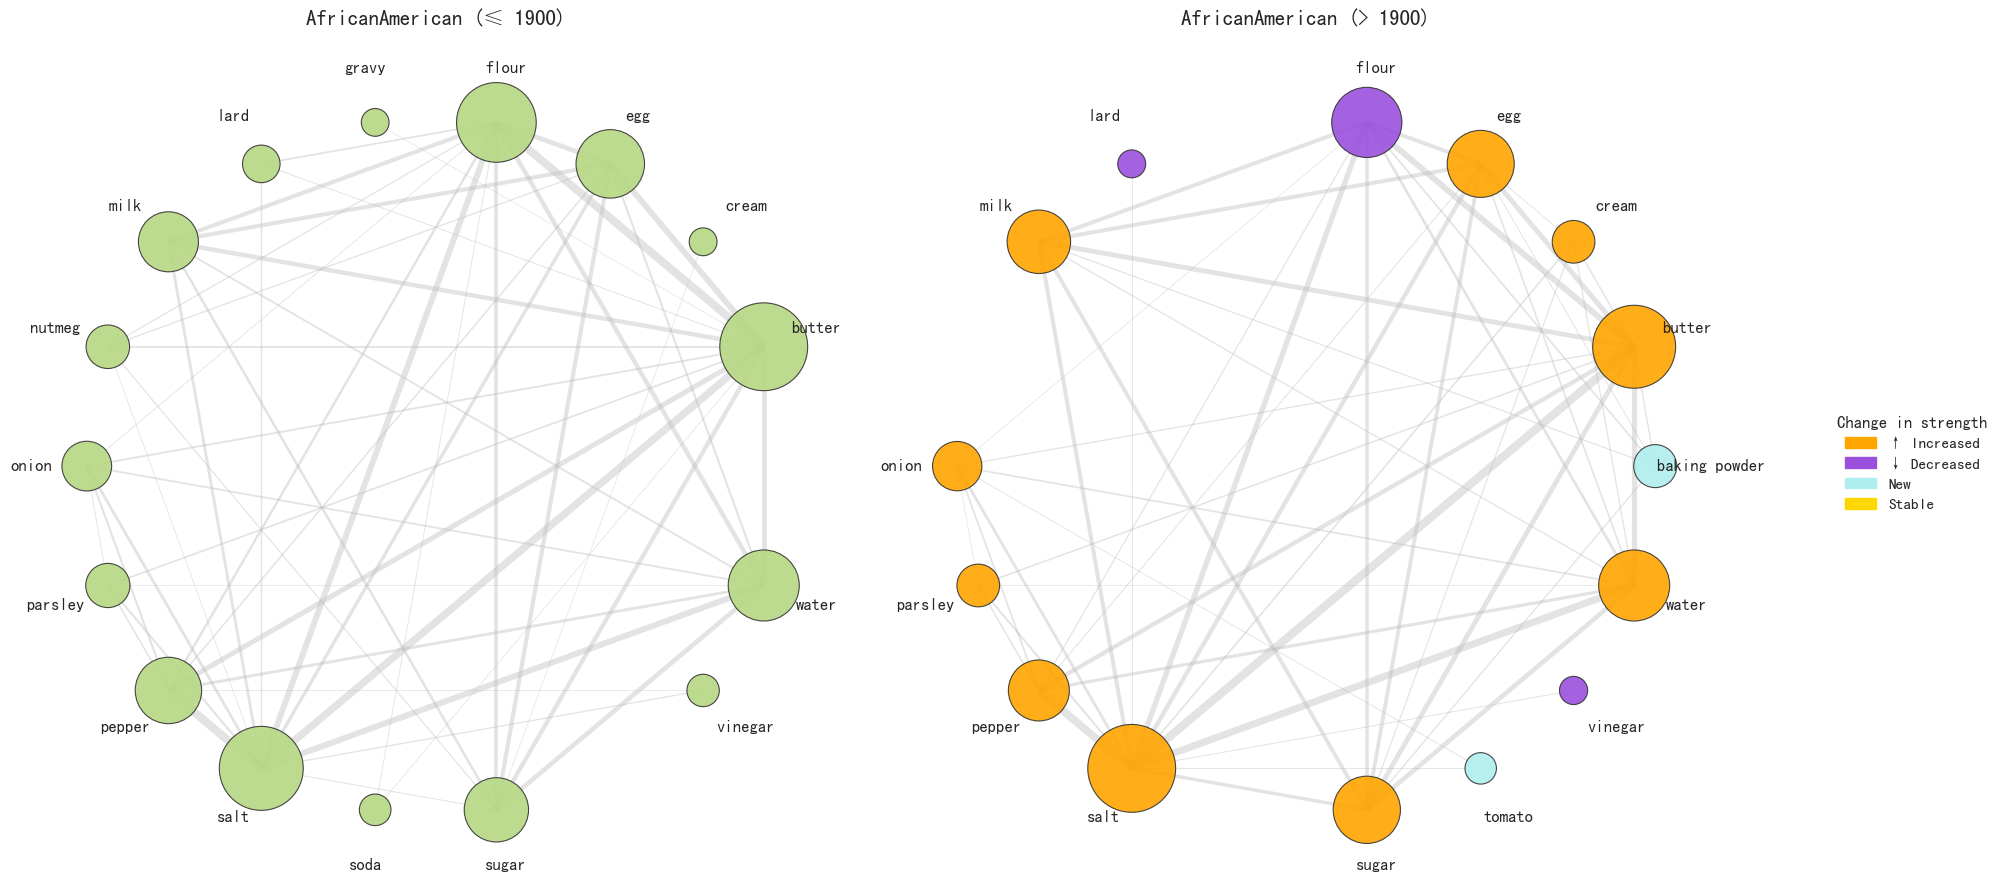

In [269]:
fig1_AfricanAmerican, fig2_AfricanAmerican, \
G1_AfricanAmerican, G2_AfricanAmerican, \
counts1_AfricanAmerican, counts2_AfricanAmerican = analyze_ingredients_by_period(
    df_books, df_recipes,
    subject_keyword="AfricanAmerican",
    split_year=1900,
    min_count=2,
    top_n=50
)
fig_AfricanAmerican = plot_period_comparison(
    G1_AfricanAmerican, counts1_AfricanAmerican,
    G2_AfricanAmerican, counts2_AfricanAmerican,
    period1_label="AfricanAmerican (≤ 1900)",
    period2_label="AfricanAmerican (> 1900)",
    delta_threshold=0
)
fig_AfricanAmerican.savefig("AfricanAmerican_1900_comparison.pdf",
                  format="pdf", bbox_inches="tight")

1827 | The House Servant's Directory黑奴的历史，更多的是反过来让黑奴去学习美国的礼仪，怎么更好的服务美国人：Complete title: The House Servant's Directory, or A Monitor for Private Families: Comprising Hints on the Arrangement and Performance of Servants' Work, with General Rules for Setting Out Tables and Sideboards in First Order; the Art of Waiting in all its Branches; and Likewise How to Conduct Large and Small Parties with Order; with General Directions for Placing on Table All Kinds of Joints, Fish, Fowl, &c. with Full Instructions for Cleaning Plate, Brass, Steel, Glass, Mahogany; and Likewise All Kinds of Patent and Common Lamps: Observations on Servants' Behaviour to their Employers; and Upwards of 100 Various and Useful Receipts, Chiefly Compiled for the Use of House Servants; and Identically Made to Suit the Manners and Customs of Families in the United States.说明african移民主要是来当黑奴 学习的是怎么服务 不是真的传入了非洲的饮食文化
从网络图也可以看出来食材的变化不大